In [13]:
import pandas as pd 
import numpy as np
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import os

### Tạo Database Profile Sinh viên (Dữ liệu tĩnh)

In [15]:

os.makedirs('dataset', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("✅ Môi trường đã sẵn sàng!")
def generate_profiles(n_students=300):
    """
    Tạo hồ sơ sinh viên gồm: Phương tiện, nhà xa, thói quen...
    """
    print("⏳ Đang khởi tạo hồ sơ sinh viên...")
    np.random.seed(42)
    ids = [f"N22DCCN{i:03d}" for i in range(1, n_students + 1)]

    profiles = []
    for sid in tqdm(ids):
        transport = np.random.choice(['Motorbike', 'Bus', 'Walk', 'Car'], p=[0.7, 0.15, 0.1, 0.05])

        # Logic: Phương tiện ảnh hưởng khoảng cách và tốc độ
        if transport == 'Walk':
            dist = np.random.uniform(0.5, 2.0)
            base_speed = 5
        elif transport == 'Bus':
            dist = np.random.uniform(5.0, 20.0)
            base_speed = 25
        else:
            dist = np.random.uniform(2.0, 30.0)
            base_speed = 35

        profiles.append({
            'student_id': sid,
            'gender': np.random.choice(['Male', 'Female']),
            'transport_mode': transport,
            'distance_km': round(dist, 2),
            'avg_speed_kmh': base_speed,
            'sleep_habit_hours': round(np.random.normal(6.5, 1.0), 1),
            'preparation_time_min': int(np.random.normal(20, 10)) if np.random.normal(20, 10) > 5 else 5,
            'alarm_used': np.random.choice(['Yes', 'No'], p=[0.85, 0.15])
        })

    df_profile = pd.DataFrame(profiles)
    df_profile.to_csv('D:\predictingStudentsLate\data\student_profiles.csv', index=False)
    print(f"✅ Đã lưu file: student_profiles.csv ({df_profile.shape[0]} records)")
    return df_profile





✅ Môi trường đã sẵn sàng!


<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:40: SyntaxWarning: invalid escape sequence '\p'
C:\Users\trita\AppData\Local\Temp\ipykernel_19432\3233678876.py:40: SyntaxWarning: invalid escape sequence '\p'
  df_profile.to_csv('D:\predictingStudentsLate\data\student_profiles.csv', index=False)


In [148]:

df = pd.read_csv(r"D:\predictingStudentsLate\student_lateness_dataset.csv")
df.head(10)

,student_id,weekday,distance_km,weather,transport_mode,avg_speed_kmh,habitual_punctuality,sleep_hours,alarm_used,hour_start_time,traffic_condition,preparation_time,unexpected_event,class_importance,is_late
0,N22DCQCN001,Monday,23.0,cloudy,bike,13.5,0.67,6.3,yes,7,moderate,34.0,no,high,yes
1,N22DCQCN002,Friday,13.6,sunny,bike,20.2,0.41,4.6,yes,9,moderate,35.0,no,low,yes
2,N22DCQCN003,Monday,1.0,sunny,bike,18.1,0.82,8.2,yes,8,heavy,29.0,no,medium,no
3,N22DCQCN004,Monday,9.7,sunny,bike,22.2,0.46,6.3,yes,7,moderate,23.0,no,low,no
4,N22DCQCN005,Tuesday,11.7,sunny,car,31.2,0.50,5.8,yes,8,moderate,55.0,no,low,yes
5,N22DCQCN006,Friday,1.0,sunny,car,35.0,0.76,6.6,no,16,heavy,51.0,no,medium,no
6,N22DCQCN007,Monday,4.2,sunny,train,44.1,0.78,8.0,yes,15,light,19.0,no,medium,no
7,N22DCQCN008,Monday,6.2,sunny,car,49.5,0.76,7.4,yes,15,light,26.0,no,medium,no
8,N22DCQCN009,NaN,12.8,sunny,bus,28.6,0.63,9.6,yes,16,moderate,49.0,no,high,yes
9,N22DCQCN010,Tuesday,21.7,rainy,bike,13.3,0.69,6.7,yes,7,moderate,39.0,yes,low,yes


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            50000 non-null  object 
 1   weekday               49999 non-null  object 
 2   distance_km           50000 non-null  float64
 3   weather               50000 non-null  object 
 4   transport_mode        50000 non-null  object 
 5   avg_speed_kmh         50000 non-null  float64
 6   habitual_punctuality  50000 non-null  float64
 7   sleep_hours           50000 non-null  float64
 8   alarm_used            50000 non-null  object 
 9   hour_start_time       50000 non-null  int64  
 10  traffic_condition     50000 non-null  object 
 11  preparation_time      50000 non-null  float64
 12  unexpected_event      50000 non-null  object 
 13  class_importance      50000 non-null  object 
 14  is_late               50000 non-null  object 
dtypes: float64(5), int6

In [150]:
df.describe()

,distance_km,avg_speed_kmh,habitual_punctuality,sleep_hours,hour_start_time,preparation_time
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,10.504400,26.992382,0.693694,6.994808,10.646740,30.590260
std,7.091872,13.279828,0.189109,1.438850,3.021948,13.551775
min,1.000000,5.000000,0.100000,4.000000,7.000000,10.000000
25%,4.600000,18.400000,0.560000,6.000000,8.000000,20.000000
50%,10.000000,24.900000,0.700000,7.000000,10.000000,30.000000
75%,15.400000,34.900000,0.830000,8.000000,13.000000,40.000000
max,30.000000,60.000000,1.000000,10.000000,16.000000,60.000000


# feature engineering 


<Axes: xlabel='preparation_time', ylabel='Count'>

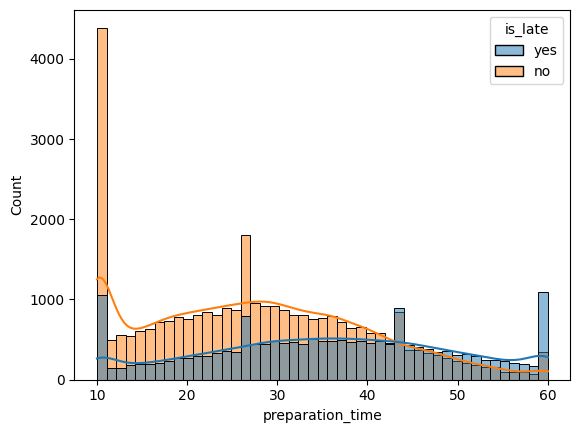

In [151]:
sns.histplot(data=df, x="preparation_time", kde="sleep_hours", hue="is_late")

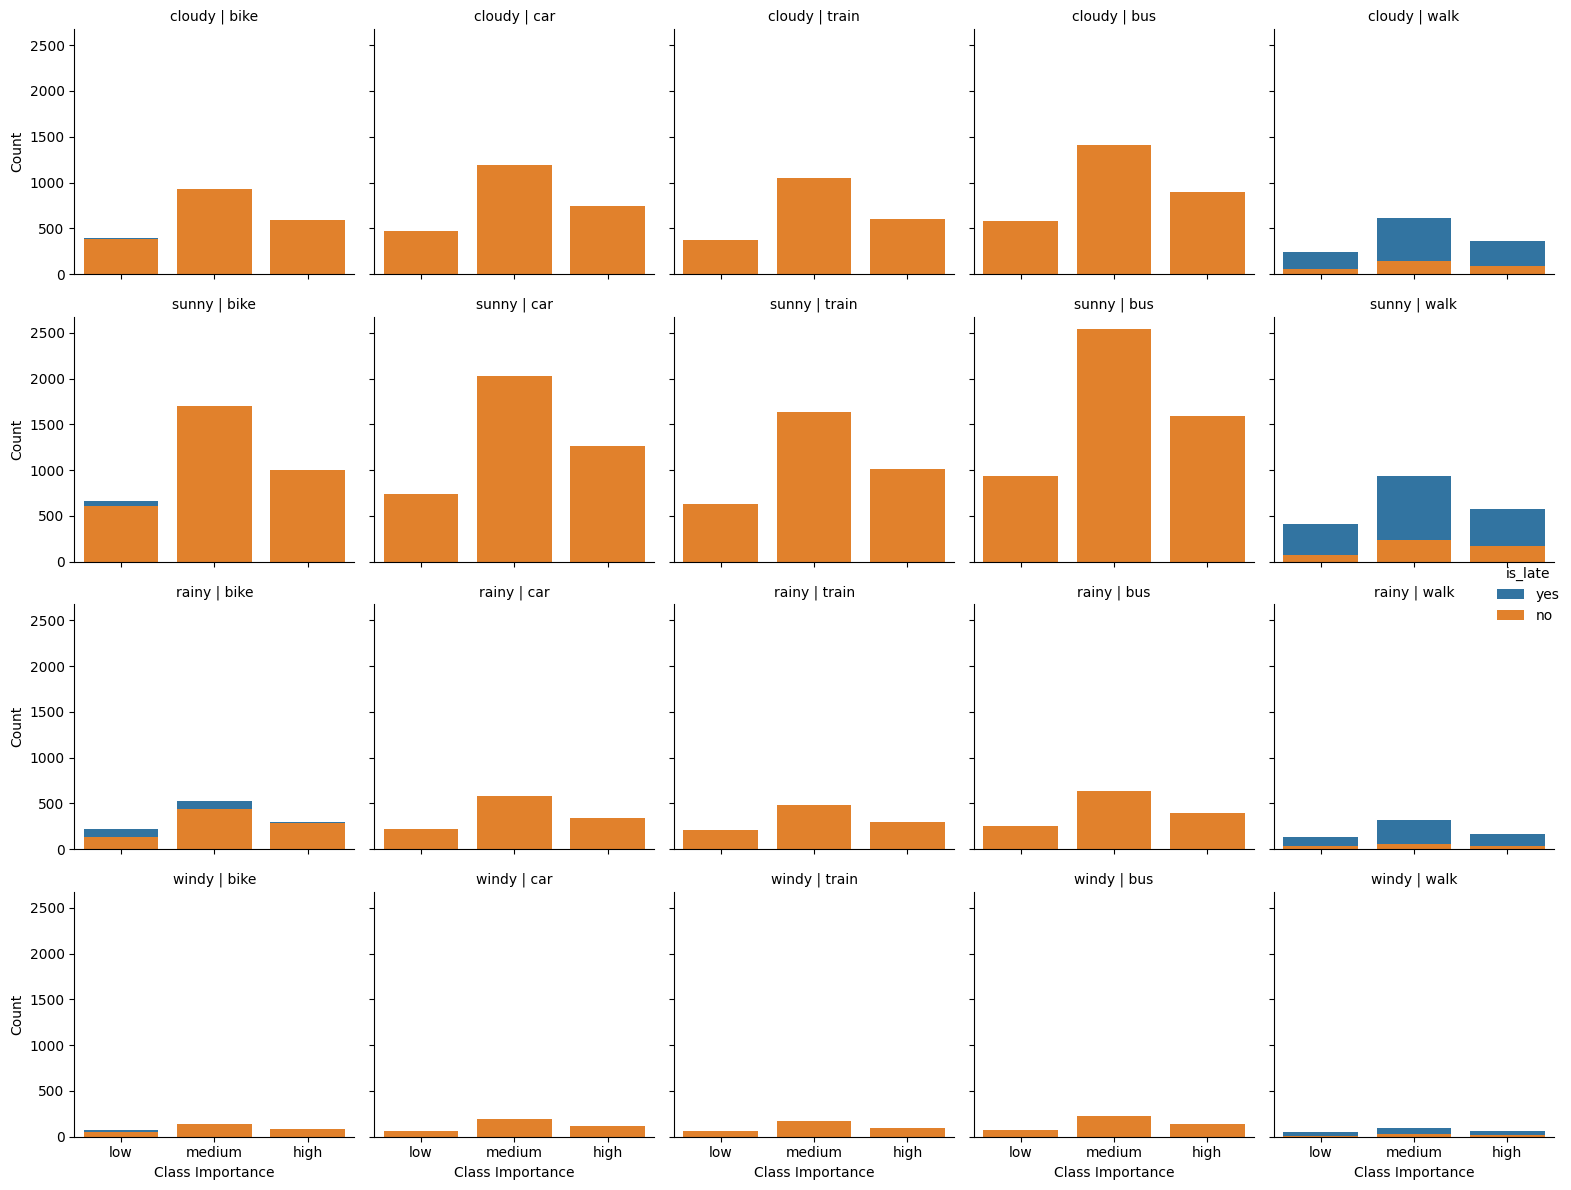

In [152]:

dis_ask = sns.FacetGrid(data=df, row="weather", col="transport_mode", hue='is_late')

dis_ask.map(sns.countplot, "class_importance", order=['low', 'medium', 'high'])
dis_ask.add_legend()
dis_ask.set_axis_labels("Class Importance", "Count")
dis_ask.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

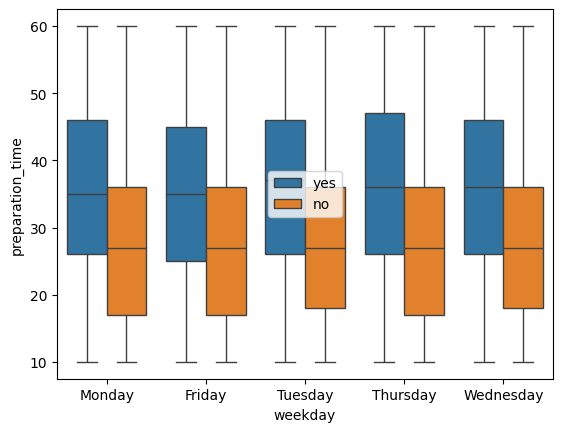

In [153]:
plt.Figure(figsize=(10, 8))
sns.boxplot(data=df, x="weekday", y="preparation_time", hue="is_late")
plt.legend(loc=10);

<Axes: xlabel='class_importance', ylabel='count'>

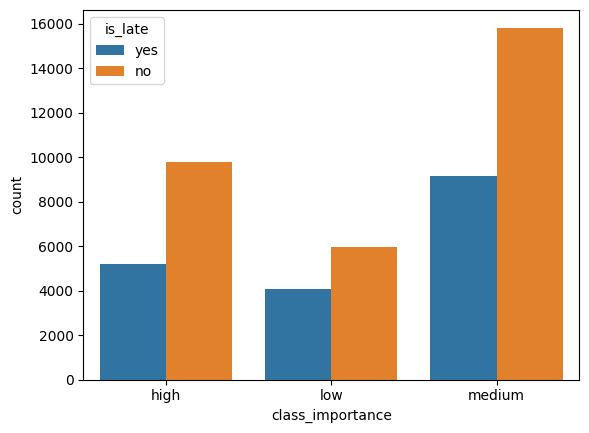

In [154]:
sns.countplot(data=df, x="class_importance", hue="is_late")

<Axes: xlabel='transport_mode', ylabel='count'>

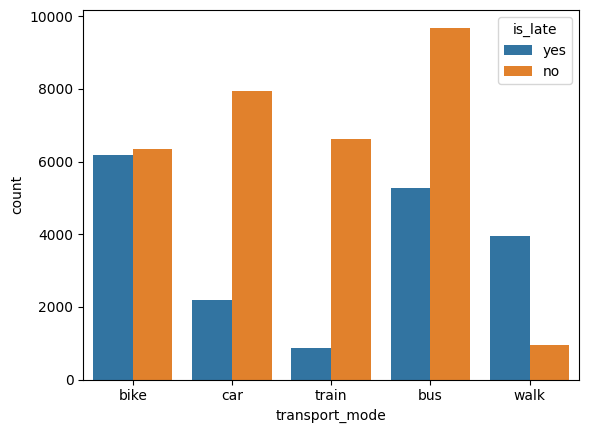

In [155]:
sns.countplot(data=df, x="transport_mode", hue='is_late')

<Axes: xlabel='is_late', ylabel='count'>

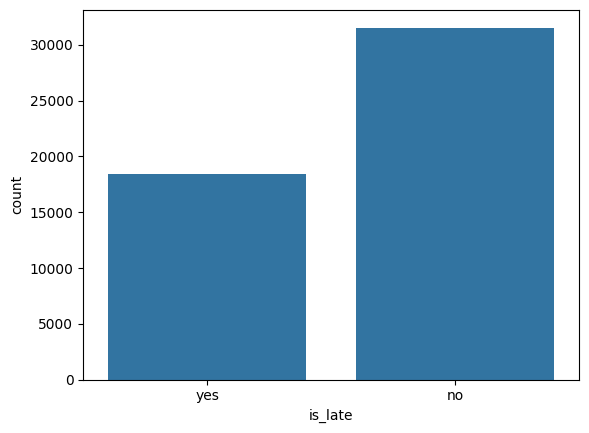

In [156]:
sns.countplot(data=df, x="is_late")

<Axes: xlabel='weather', ylabel='count'>

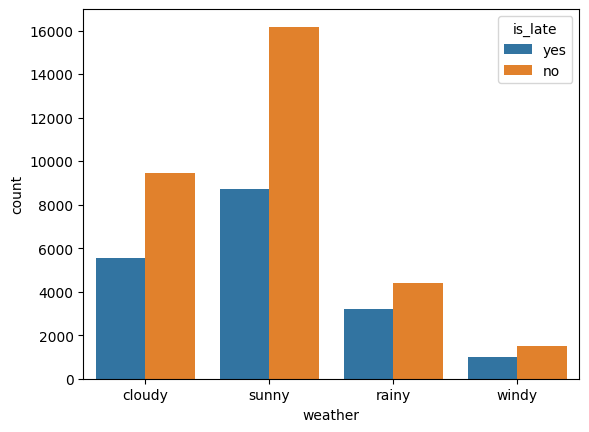

In [157]:
sns.countplot(data=df, x="weather", hue="is_late")

<Axes: xlabel='is_late', ylabel='count'>

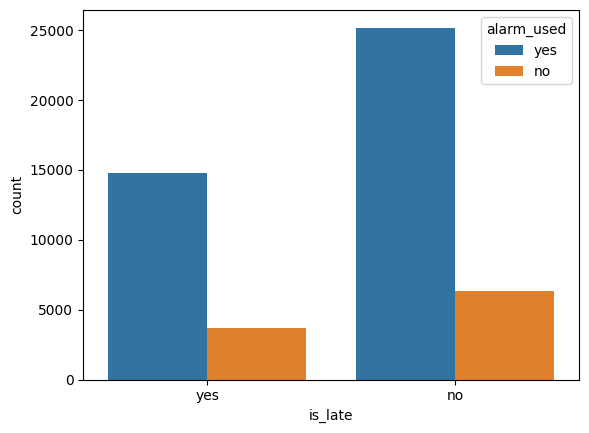

In [158]:
sns.countplot(data=df, x="is_late", hue="alarm_used")

# Data wrangling 

In [159]:
# xử lý dữ liệu datime
# df["start_time"] = pd.to_datetime(df["class_start_time"], format='%H:%M') # chuyển từ string sang datetime
# df["hour_start_time"] = df["start_time"].dt.hour


In [160]:
# df_test["start_time"] = pd.to_datetime(df_test["class_start_time"], format='%H:%M') # chuyển từ string sang datetime
# df_test["hour_start_time"] = df_test["start_time"].dt.hour

In [161]:
# features = ["class_start_time", "start_time"]
# df = df.drop(features, axis=1, errors="ignore")
# df_test = df_test.drop(features, axis=1, errors="ignore")



In [162]:
cat_feature = ["weekday", "weather", "transport_mode", "alarm_used", "traffic_condition", "unexpected_event", "class_importance"]
num_feature = ["distance_km", "avg_speed_kmh", "habitual_punctuality", "sleep_hours", "hour_start_time", "preparation_time"]

feature_col = cat_feature + num_feature 

In [163]:
def convert_df(df, cat_feature):
    for featue in cat_feature:
        df[featue] = df[featue].astype("category")


convert_df(df, cat_feature)

# df.describe(include=["category"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   student_id            50000 non-null  object  
 1   weekday               49999 non-null  category
 2   distance_km           50000 non-null  float64 
 3   weather               50000 non-null  category
 4   transport_mode        50000 non-null  category
 5   avg_speed_kmh         50000 non-null  float64 
 6   habitual_punctuality  50000 non-null  float64 
 7   sleep_hours           50000 non-null  float64 
 8   alarm_used            50000 non-null  category
 9   hour_start_time       50000 non-null  int64   
 10  traffic_condition     50000 non-null  category
 11  preparation_time      50000 non-null  float64 
 12  unexpected_event      50000 non-null  category
 13  class_importance      50000 non-null  category
 14  is_late               50000 non-null  object  
dtypes:

In [164]:

def check_missing_col(df, feature_col):
    for col in feature_col:
        missing_count = df[col].isnull().sum()
        if missing_count >= 0:   
          print(f"col: {col}\n missing precent: {missing_count/len(df)*100}%")
            
check_missing_col(df, feature_col)


col: weekday
 missing precent: 0.002%
col: weather
 missing precent: 0.0%
col: transport_mode
 missing precent: 0.0%
col: alarm_used
 missing precent: 0.0%
col: traffic_condition
 missing precent: 0.0%
col: unexpected_event
 missing precent: 0.0%
col: class_importance
 missing precent: 0.0%
col: distance_km
 missing precent: 0.0%
col: avg_speed_kmh
 missing precent: 0.0%
col: habitual_punctuality
 missing precent: 0.0%
col: sleep_hours
 missing precent: 0.0%
col: hour_start_time
 missing precent: 0.0%
col: preparation_time
 missing precent: 0.0%


In [165]:

# kiểm tra dữ liệu có bị missing không 
def cneck_col_nan (df, feature_col):
    for col in df.columns:
        missing = df[col].isna().sum()
        if missing >= 0:
            missing_precent = missing/len(df)*100
            print(f"col: {col}\n missing precent: {missing_precent}%")
            
check_missing_col(df, feature_col)



col: weekday
 missing precent: 0.002%
col: weather
 missing precent: 0.0%
col: transport_mode
 missing precent: 0.0%
col: alarm_used
 missing precent: 0.0%
col: traffic_condition
 missing precent: 0.0%
col: unexpected_event
 missing precent: 0.0%
col: class_importance
 missing precent: 0.0%
col: distance_km
 missing precent: 0.0%
col: avg_speed_kmh
 missing precent: 0.0%
col: habitual_punctuality
 missing precent: 0.0%
col: sleep_hours
 missing precent: 0.0%
col: hour_start_time
 missing precent: 0.0%
col: preparation_time
 missing precent: 0.0%


In [166]:
from sklearn.impute import SimpleImputer
# hàm sử dụng để kiểm tra các giá trị nan và lấp đầy và thay thế chúng 
def imputer_missing_value(df):
    if isinstance(df, pd.DataFrame):
        find_missing_value = df.columns[df.isna().any()].to_list()
        if find_missing_value:
            imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
            df[find_missing_value] = imputer.fit(df[find_missing_value])
        return df
    else:
        df = np.array()
        if df.ndim == 1:
            df = df.reshape(-1, 1)
            find_col_missing = np.any(np.isnan(), axis=0)
            if find_col_missing:
                imputer = SimpleImputer(missing_values=np.nan, strategy="mean")
                df[:, find_col_missing] = imputer.fit(df[:, find_col_missing])
            return df
imputer_missing_value(df.head(5))
# imputer_missing_value(df_test.head(5))

,student_id,weekday,distance_km,weather,transport_mode,avg_speed_kmh,habitual_punctuality,sleep_hours,alarm_used,hour_start_time,traffic_condition,preparation_time,unexpected_event,class_importance,is_late
0,N22DCQCN001,Monday,23.0,cloudy,bike,13.5,0.67,6.3,yes,7,moderate,34.0,no,high,yes
1,N22DCQCN002,Friday,13.6,sunny,bike,20.2,0.41,4.6,yes,9,moderate,35.0,no,low,yes
2,N22DCQCN003,Monday,1.0,sunny,bike,18.1,0.82,8.2,yes,8,heavy,29.0,no,medium,no
3,N22DCQCN004,Monday,9.7,sunny,bike,22.2,0.46,6.3,yes,7,moderate,23.0,no,low,no
4,N22DCQCN005,Tuesday,11.7,sunny,car,31.2,0.50,5.8,yes,8,moderate,55.0,no,low,yes


In [167]:
duplicate_rows = df.duplicated().sum()
print(f'\n--- Số hàng trùng lặp: {duplicate_rows} ---')
print('\n--- Hàng trùng lặp trong dataset ---')
print(df[df.duplicated(keep=False)].head(15))
df = df.drop_duplicates(keep='first')
print(f'Số hàng sau khi loại bỏ trùng lặp: {df.shape[0]}')


--- Số hàng trùng lặp: 0 ---

--- Hàng trùng lặp trong dataset ---
Empty DataFrame
Columns: [student_id, weekday, distance_km, weather, transport_mode, avg_speed_kmh, habitual_punctuality, sleep_hours, alarm_used, hour_start_time, traffic_condition, preparation_time, unexpected_event, class_importance, is_late]
Index: []
Số hàng sau khi loại bỏ trùng lặp: 50000


In [168]:
from sklearn.datasets import make_classification
from collections import Counter
X, Y = make_classification(n_samples=len(df), n_features=2, n_redundant=0,
	n_clusters_per_class=1, weights=[0.99], flip_y=0, random_state=2)


In [169]:
counter = Counter(Y)
print(counter)

Counter({np.int64(0): 49500, np.int64(1): 500})


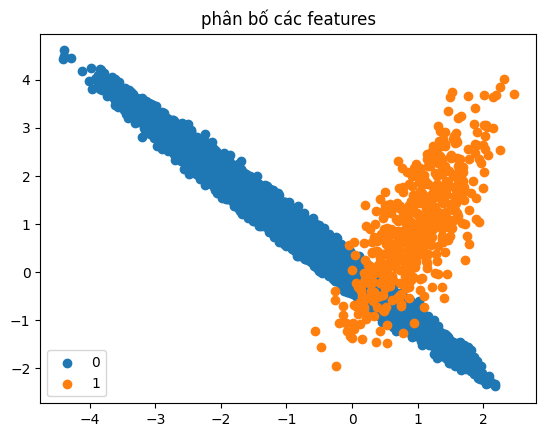

In [170]:

from numpy import where
for label, _ in counter.items():
	row_ix = where(Y == label)[0]
	plt.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
plt.legend()
plt.title("phân bố các features")
plt.show()

In [171]:

x = df[feature_col]
# x_test = df_test
x


,weekday,weather,transport_mode,alarm_used,traffic_condition,unexpected_event,class_importance,distance_km,avg_speed_kmh,habitual_punctuality,sleep_hours,hour_start_time,preparation_time
0,Monday,cloudy,bike,yes,moderate,no,high,23.0,13.5,0.67,6.3,7,34.0
1,Friday,sunny,bike,yes,moderate,no,low,13.6,20.2,0.41,4.6,9,35.0
2,Monday,sunny,bike,yes,heavy,no,medium,1.0,18.1,0.82,8.2,8,29.0
3,Monday,sunny,bike,yes,moderate,no,low,9.7,22.2,0.46,6.3,7,23.0
4,Tuesday,sunny,car,yes,moderate,no,low,11.7,31.2,0.50,5.8,8,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Monday,windy,train,yes,moderate,no,high,17.3,34.9,0.74,7.9,14,45.0
49996,Thursday,cloudy,car,yes,light,no,medium,13.8,33.7,0.64,8.3,15,33.0
49997,Wednesday,sunny,car,yes,light,no,high,1.5,28.7,0.86,7.8,13,37.0
49998,Tuesday,cloudy,bike,yes,heavy,no,medium,9.2,16.9,0.83,7.8,9,29.0


In [172]:
y = df["is_late"]
y.head(10)

0    yes
1    yes
2     no
3     no
4    yes
5     no
6     no
7     no
8    yes
9    yes
Name: is_late, dtype: object

### Encode Dependent variable(y)

In [173]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
y

array([1, 1, 0, ..., 0, 1, 0], shape=(50000,))

### preprocess pipeline

In [174]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_tranformer = Pipeline(steps=[
     ("imputer", SimpleImputer(strategy="mean")),
     ("scaler", StandardScaler())
])

cat_tranformer = Pipeline(steps=[
     ("imputer", SimpleImputer(strategy="most_frequent")), # lấy giá trị xuất hiện nhiều nhất
     ("endcoder", OneHotEncoder(handle_unknown="ignore"))
])
    

In [ ]:

preprocessor = ColumnTransformer(transformers=[
    ("num", num_tranformer, num_feature),
    ("cat", cat_tranformer, cat_feature),
])
preprocessor.fit(x)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['distance_km', 'avg_speed_kmh',
                                  'habitual_punctuality', 'sleep_hours',
                                  'hour_start_time', 'preparation_time']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('endcoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['weekday', 'weather', 'transport_mode',
                                  'alarm_used', 'traffic_condition',
                                  'unexpected_event', 'class_importance'])])

 ### Encode Dependent variable(x)

In [176]:
x = preprocessor.transform(x)
# x_test = preprocessor.transform(x_test)

In [177]:
for i in range(x.shape[1]):
    missing = np.isnan(x[:, i]).sum()  # kiểm tra NaN trên cột i
    missing_percent = missing / x.shape[0] * 100
    print(f"col {i} missing percent: {missing_percent}%")

col 0 missing percent: 0.0%
col 1 missing percent: 0.0%
col 2 missing percent: 0.0%
col 3 missing percent: 0.0%
col 4 missing percent: 0.0%
col 5 missing percent: 0.0%
col 6 missing percent: 0.0%
col 7 missing percent: 0.0%
col 8 missing percent: 0.0%
col 9 missing percent: 0.0%
col 10 missing percent: 0.0%
col 11 missing percent: 0.0%
col 12 missing percent: 0.0%
col 13 missing percent: 0.0%
col 14 missing percent: 0.0%
col 15 missing percent: 0.0%
col 16 missing percent: 0.0%
col 17 missing percent: 0.0%
col 18 missing percent: 0.0%
col 19 missing percent: 0.0%
col 20 missing percent: 0.0%
col 21 missing percent: 0.0%
col 22 missing percent: 0.0%
col 23 missing percent: 0.0%
col 24 missing percent: 0.0%
col 25 missing percent: 0.0%
col 26 missing percent: 0.0%
col 27 missing percent: 0.0%
col 28 missing percent: 0.0%
col 29 missing percent: 0.0%


# split x_train, y_train, x_val, y_val

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

x_train, x_val, y_train, y_val = train_test_split(x, y, train_size=0.8, test_size=0.2, random_state=42) # không bị xáo trộn

print(f"Train size: {len(x_train)}")
print(f"Val size: {len(x_val)}")


Train size: 32000
Val size: 8000
Test size: 10000


### Smote (sử dụng để cân bằng nhãn)

In [179]:
print(f"Số lượng mẫu trước SMOTE: {y_train}")

Số lượng mẫu trước SMOTE: [1 1 1 ... 1 1 0]


In [180]:
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

In [181]:

print(f"Số lượng mẫu sau SMOTE: {y_train}")

Số lượng mẫu sau SMOTE: [1 1 1 ... 1 1 1]


In [182]:
x_train, x_val, x_test

(array([[-0.71976073, -1.65609083, -1.13001566, ...,  1.        ,
          0.        ,  0.        ],
        [ 1.6773736 , -0.72986478, -0.81273486, ...,  0.        ,
          0.        ,  1.        ],
        [ 1.31075305, -0.42112276, -0.28393353, ...,  0.        ,
          0.        ,  1.        ],
        ...,
        [ 0.30217558, -1.65404313,  1.19763825, ...,  0.        ,
          1.        ,  0.        ],
        [ 2.22179498, -0.43134635,  0.16747388, ...,  0.38410681,
          0.        ,  0.61589319],
        [ 1.18848866, -0.36594777,  0.24086765, ...,  1.        ,
          0.        ,  0.        ]], shape=(40506, 30)),
 array([[ 0.0980851 , -0.07472927,  0.13910754, ...,  0.        ,
          0.        ,  1.        ],
        [-0.87486943,  0.01563424,  1.14383006, ...,  0.        ,
          0.        ,  1.        ],
        [ 0.6621167 , -0.50395598, -0.01953286, ...,  1.        ,
          0.        ,  0.        ],
        ...,
        [ 1.71967597, -0.76751624, 

In [183]:
y_train, y_val, y_test


(array([1, 1, 1, ..., 1, 1, 1], shape=(40506,)),
 array([0, 0, 1, ..., 1, 0, 0], shape=(8000,)),
 array([0, 0, 1, ..., 0, 1, 0], shape=(10000,)))

# Training model

### LogisticRegression

In [184]:
from sklearn.preprocessing import PolynomialFeatures # áp dụng tằng kĩ thuật tăng bậc 
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

In [185]:
log_reg = LogisticRegression( max_iter=1000, random_state=42, class_weight='balanced')
log_reg.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [ ]:
print(f"Accuracy on val set: {log_reg.score(x_val, y_val)}")
print(f"Accuracy on train set: {log_reg.score(x_train, y_train)}")

Accuracy on val set: 0.92525
Accuracy on test set: 0.9318
Accuracy on train set: 0.9284303559966425


In [187]:
# du doan xac xuat di của index đầu tiên trong tập val
first_preson = x_val[0:1]
prob = log_reg.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.92
Xác suất đi trễ (Lớp 1): 0.08


In [ ]:
# du doan xac xuat di của index đầu tiên trong tập test
first_preson = x_val[0:1]
prob = log_reg.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.85
Xác suất đi trễ (Lớp 1): 0.15


In [ ]:
y_pred_val = log_reg.predict(x_val)

prediction_val = pd.DataFrame({"y": y_val, "y_pred_val": y_pred_val})
prediction_val.head(10)

,y,y_pred_val
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [190]:
prediction_test = pd.DataFrame({"y": y_test, "y_pred_test": y_pred_test})
prediction_test.head(10)

,y,y_pred_test
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [191]:
precision_score(y_test, y_pred_test),  recall_score(y_test, y_pred_test)     

(0.882221671212497, 0.9450199203187251)

In [192]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.97      0.92      0.94      6235
           1       0.88      0.95      0.91      3765

    accuracy                           0.93     10000
   macro avg       0.92      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



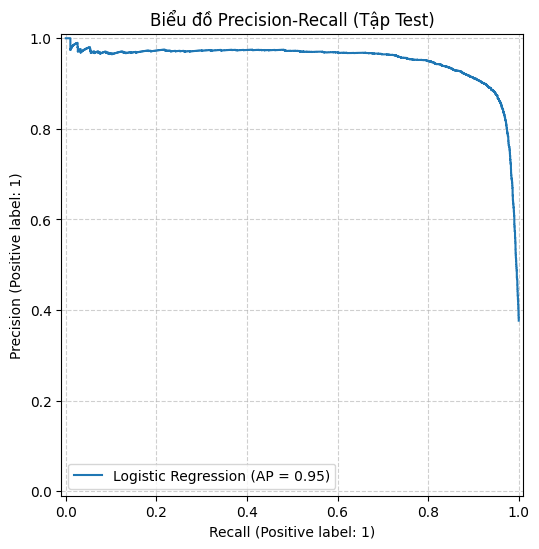

In [193]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(log_reg, x_test, y_test, name="Logistic Regression", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập Test)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

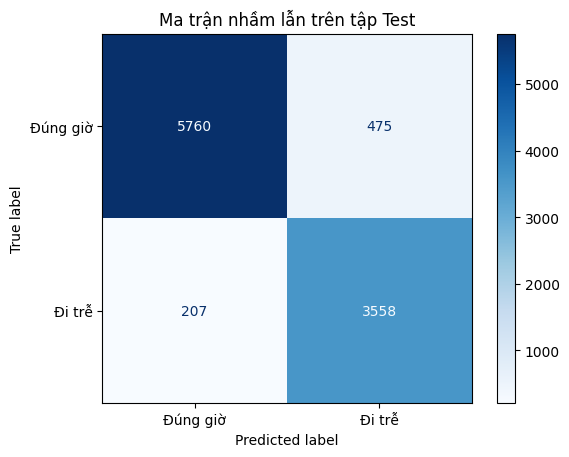

In [194]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(log_reg, x_test, y_test, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()

<Figure size 800x600 with 0 Axes>

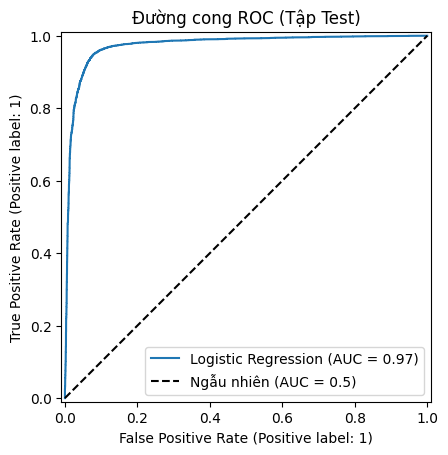

In [195]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(log_reg, x_test, y_test, name="Logistic Regression")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập Test)')
plt.legend()
plt.show()

In [196]:
precision_score(y_val, y_pred_val),  recall_score(y_val, y_pred_val)

(0.8688111005991801, 0.9380320054477358)

In [197]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      5063
           1       0.87      0.94      0.90      2937

    accuracy                           0.93      8000
   macro avg       0.92      0.93      0.92      8000
weighted avg       0.93      0.93      0.93      8000



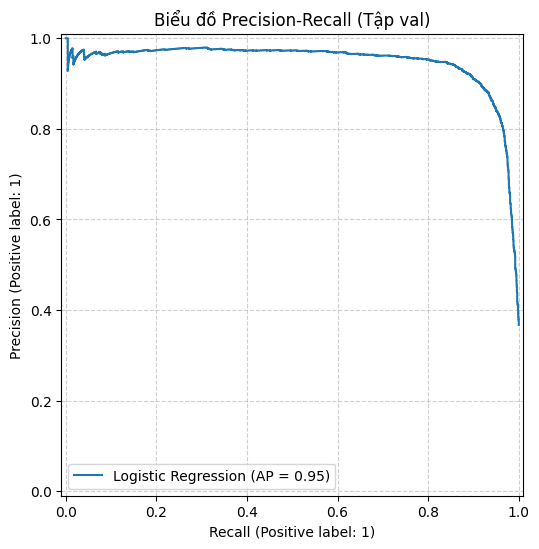

In [198]:
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(log_reg, x_val, y_val,  name="Logistic Regression", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập val)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

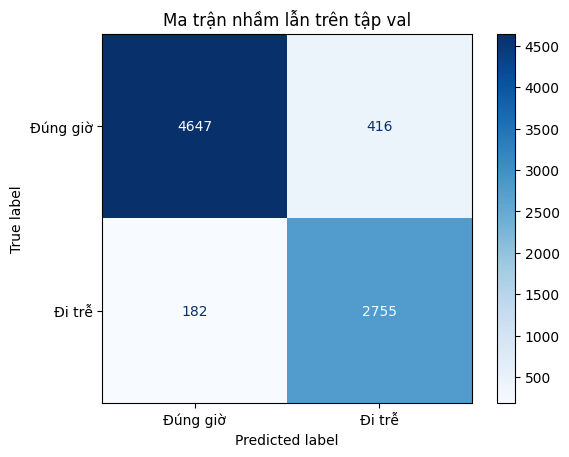

In [199]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(log_reg, x_val, y_val, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập val')
plt.show()

<Figure size 800x600 with 0 Axes>

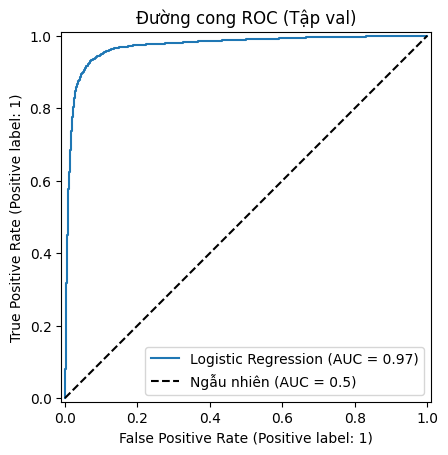

In [200]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(log_reg, x_val, y_val, name="Logistic Regression")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập val)')
plt.legend()
plt.show()

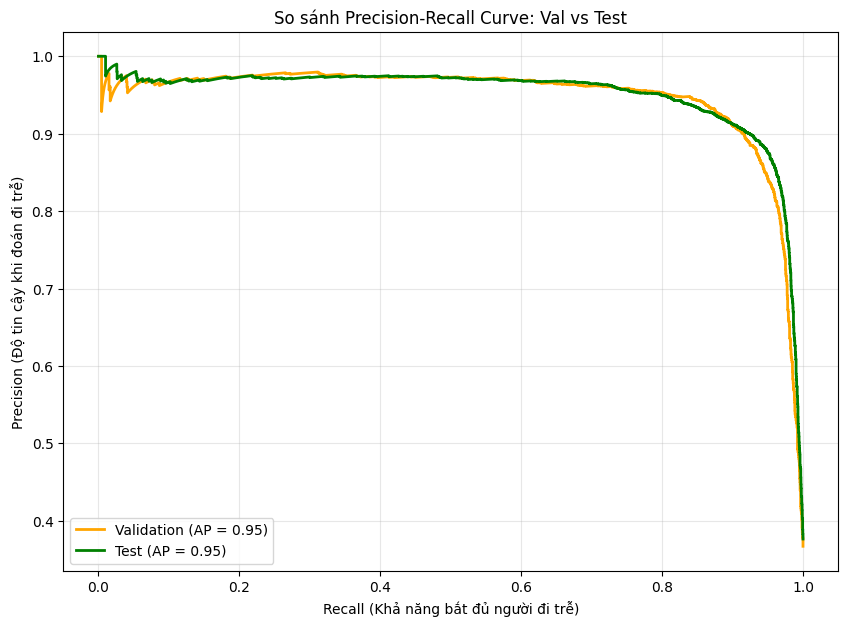

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_prob_val = log_reg.predict_proba(x_val)[:, 1]
y_prob_train = log_reg.predict_proba(x_train)[:, 1]

p_val, r_val, _ = precision_recall_curve(y_val, y_prob_val)
p_train, r_train, _ = precision_recall_curve(y_train, y_prob_train)

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))
plt.plot(r_val, p_val, label=f'Validation (AP = {average_precision_score(y_val, y_prob_val):.2f})', color='orange', lw=2)
plt.plot(r_train, p_train, label=f'Test (AP = {average_precision_score(y_train, y_prob_train):.2f})', color='green', lw=2)

plt.xlabel('Recall (Khả năng bắt đủ người đi trễ)')
plt.ylabel('Precision (Độ tin cậy khi đoán đi trễ)')
plt.title('So sánh Precision-Recall Curve: Val vs Test')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

### DecisionTreeClassifier model

In [202]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    criterion='gini',          
    max_depth=10,             
    min_samples_split=20,      
    min_samples_leaf=10,       
    max_features='sqrt',    
    class_weight='balanced',   
    random_state=42
)
dt.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       max_features='sqrt', min_samples_leaf=10,
                       min_samples_split=20, random_state=42)

In [203]:
print(f"Accuracy on val set: {dt.score(x_val, y_val)}")
print(f"Accuracy on test set: {dt.score(x_test, y_test)}")
print(f"Accuracy on train set: {dt.score(x_train, y_train)}")

Accuracy on val set: 0.879375
Accuracy on test set: 0.8851
Accuracy on train set: 0.9027798350861601


In [204]:
# du doan xac xuat di của index đầu tiên trong tập val
first_preson = x_val[0:1]
prob = dt.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 1.00
Xác suất đi trễ (Lớp 1): 0.00


In [205]:
# du doan xac xuat di của index đầu tiên trong tập test
first_preson = x_test[0:1]
prob = dt.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.19
Xác suất đi trễ (Lớp 1): 0.81


In [206]:
y_pred_test = dt.predict(x_test)
y_pred_val = dt.predict(x_val)

prediction_val = pd.DataFrame({"y": y_val, "y_pred_val": y_pred_val})
prediction_val.head(10)

,y,y_pred_val
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [207]:
prediction_test = pd.DataFrame({"y": y_test, "y_pred_test": y_pred_test})
prediction_test.head(10)

,y,y_pred_test
0,0,1
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [208]:
precision_score(y_test, y_pred_test),  recall_score(y_test, y_pred_test)     

(0.8291394061399094, 0.8751660026560425)

In [209]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      6235
           1       0.83      0.88      0.85      3765

    accuracy                           0.89     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.89      0.89      0.89     10000



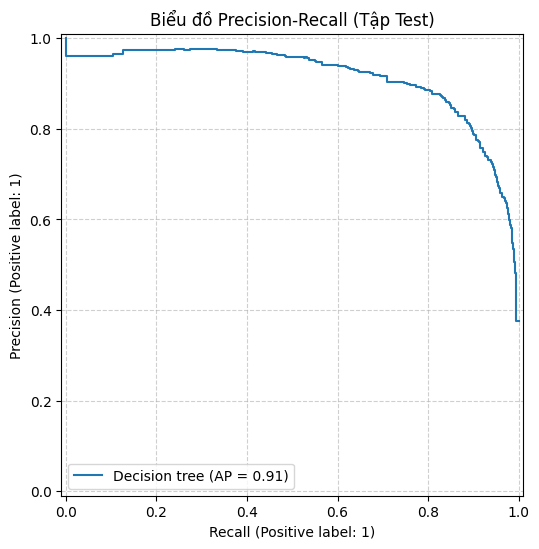

In [210]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(dt, x_test, y_test, name="Decision tree", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập Test)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

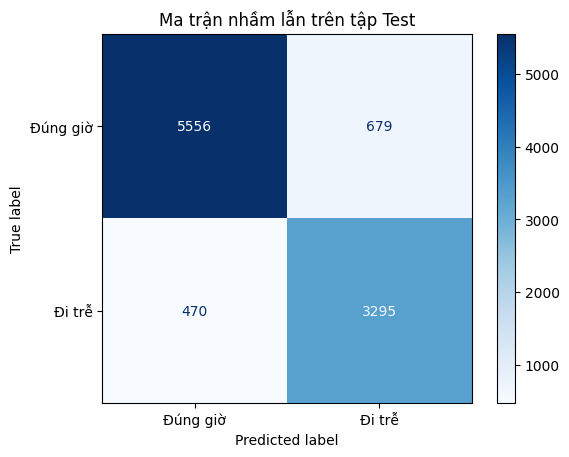

In [211]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(dt, x_test, y_test, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()

<Figure size 800x600 with 0 Axes>

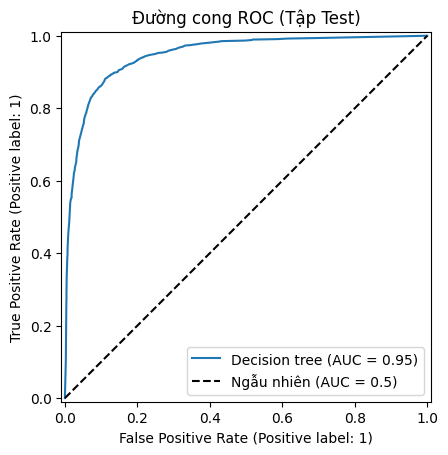

In [212]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(dt, x_test, y_test, name="Decision tree")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập Test)')
plt.legend()
plt.show()

In [213]:
precision_score(y_val, y_pred_val),  recall_score(y_val, y_pred_val)

(0.8142128744423199, 0.8699353081375554)

In [214]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.92      0.88      0.90      5063
           1       0.81      0.87      0.84      2937

    accuracy                           0.88      8000
   macro avg       0.87      0.88      0.87      8000
weighted avg       0.88      0.88      0.88      8000



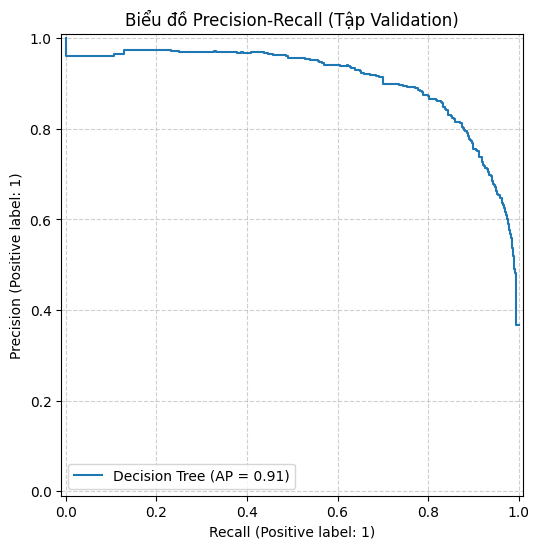

In [215]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(dt, x_val, y_val, name="Decision Tree", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập Validation)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

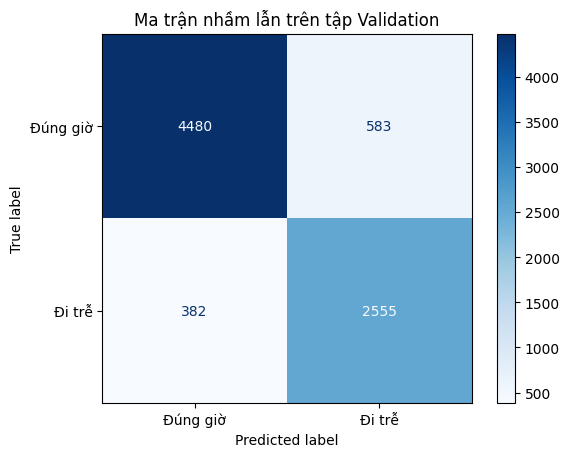

In [216]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(dt, x_val, y_val, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập Validation')
plt.show()

<Figure size 800x600 with 0 Axes>

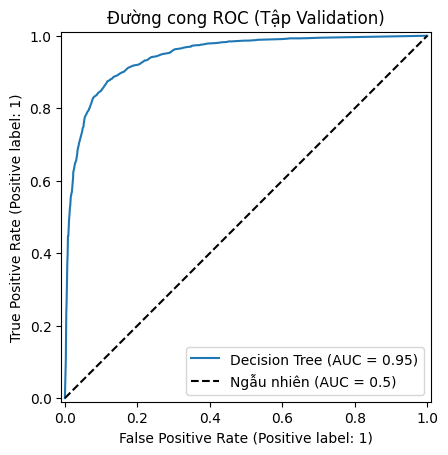

In [217]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(dt, x_val, y_val, name="Decision Tree")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập Validation)')
plt.legend()
plt.show()

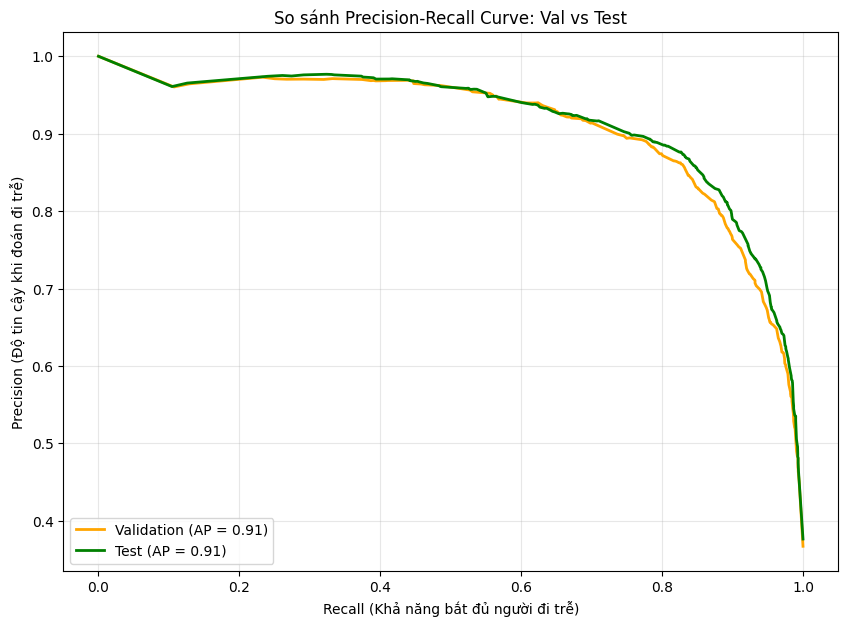

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_prob_val = dt.predict_proba(x_val)[:, 1]
y_prob_train = dt.predict_proba(x_train)[:, 1]

p_val, r_val, _ = precision_recall_curve(y_val, y_prob_val)
p_train, r_train, _ = precision_recall_curve(y_train, y_prob_train)

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))
plt.plot(r_val, p_val, label=f'Validation (AP = {average_precision_score(y_val, y_prob_val):.2f})', color='orange', lw=2)
plt.plot(r_train, p_train, label=f'Test (AP = {average_precision_score(y_train, y_prob_train):.2f})', color='green', lw=2)

plt.xlabel('Recall (Khả năng bắt đủ người đi trễ)')
plt.ylabel('Precision (Độ tin cậy khi đoán đi trễ)')
plt.title('So sánh Precision-Recall Curve: Val vs Train')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

### RandomForestClassifier model

In [219]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,        
    max_depth=10,            
    min_samples_split=10,  
    min_samples_leaf=5,     
    max_features='sqrt',   
    class_weight='balanced', 
    random_state=42,
)

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [ ]:
print(f"Accuracy on val set: {rf.score(x_val, y_val)}")
print(f"Accuracy on train set: {rf.score(x_train, y_train)}")

Accuracy on val set: 0.932875
Accuracy on test set: 0.9319
Accuracy on train set: 0.9604009282575421


In [221]:
# du doan xac xuat của index đầu tiên trong tập val
first_preson = x_val[0:1]
prob = rf.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.79
Xác suất đi trễ (Lớp 1): 0.21


In [222]:
# du doan xac xuat của index đầu tiên trong tập test
first_preson = x_test[0:1]
prob = rf.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.51
Xác suất đi trễ (Lớp 1): 0.49


In [ ]:
y_pred_val = rf.predict(x_val)

prediction_val = pd.DataFrame({"y": y_val, "y_pred_val": y_pred_val})
prediction_val.head(10)

,y,y_pred_val
0,0,0
1,0,0
2,1,1
3,1,0
4,0,0
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [224]:
prediction_test = pd.DataFrame({"y": y_test, "y_pred_test": y_pred_test})
prediction_test.head(10)

,y,y_pred_test
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [225]:
precision_score(y_test, y_pred_test),  recall_score(y_test, y_pred_test)     

(0.8923664122137405, 0.9314741035856574)

In [226]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      6235
           1       0.89      0.93      0.91      3765

    accuracy                           0.93     10000
   macro avg       0.92      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



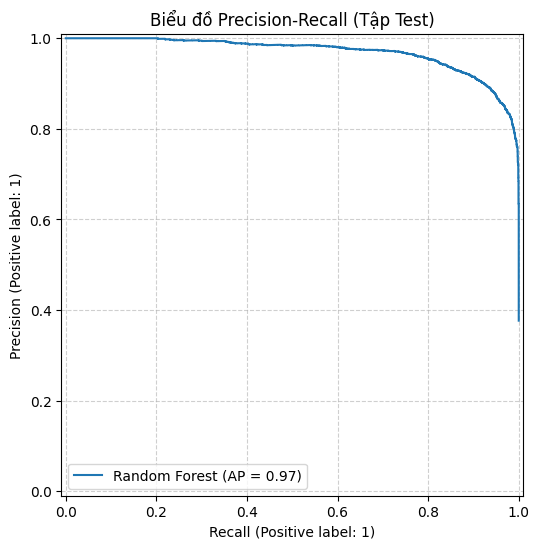

In [227]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(rf, x_test, y_test, name="Random Forest", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập Test)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

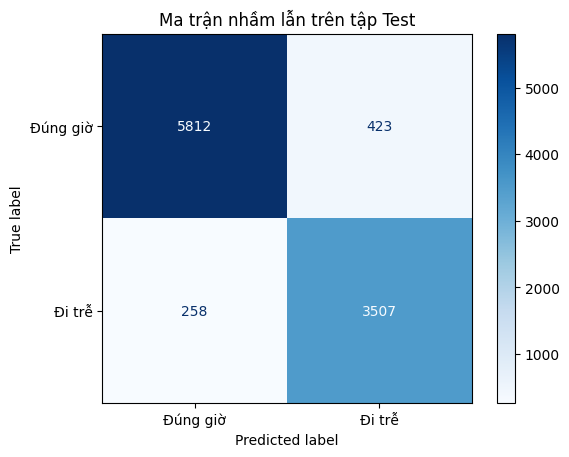

In [228]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf, x_test, y_test, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()

<Figure size 800x600 with 0 Axes>

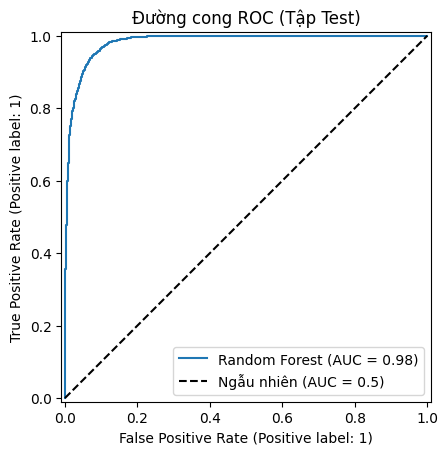

In [229]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, x_test, y_test, name="Random Forest")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập Test)')
plt.legend()
plt.show()

In [230]:
precision_score(y_val, y_pred_val),  recall_score(y_val, y_pred_val)     

(0.8853564547206165, 0.9387129724208376)

In [231]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      5063
           1       0.89      0.94      0.91      2937

    accuracy                           0.93      8000
   macro avg       0.92      0.93      0.93      8000
weighted avg       0.93      0.93      0.93      8000



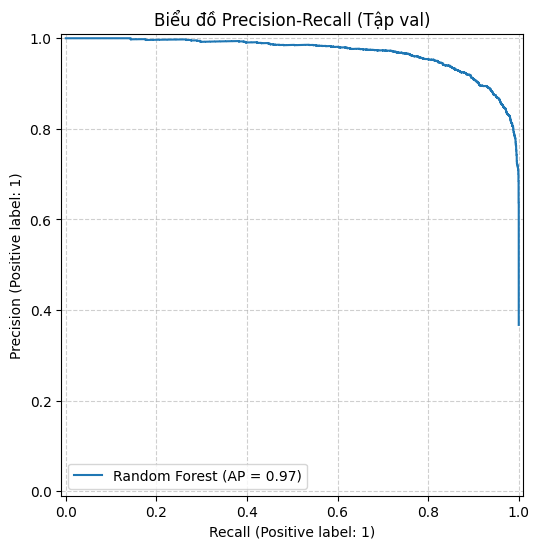

In [232]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(rf, x_val, y_val, name="Random Forest", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập val)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

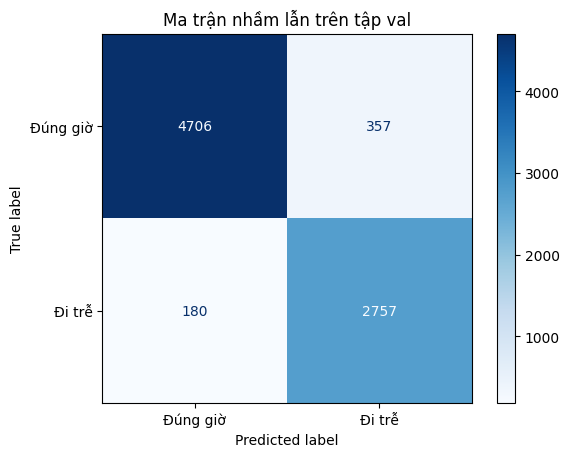

In [233]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(rf, x_val, y_val, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập val')
plt.show()

<Figure size 800x600 with 0 Axes>

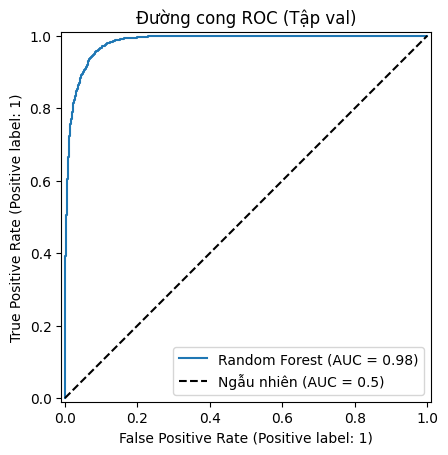

In [234]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf, x_val, y_val, name="Random Forest")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập val)')
plt.legend()
plt.show()

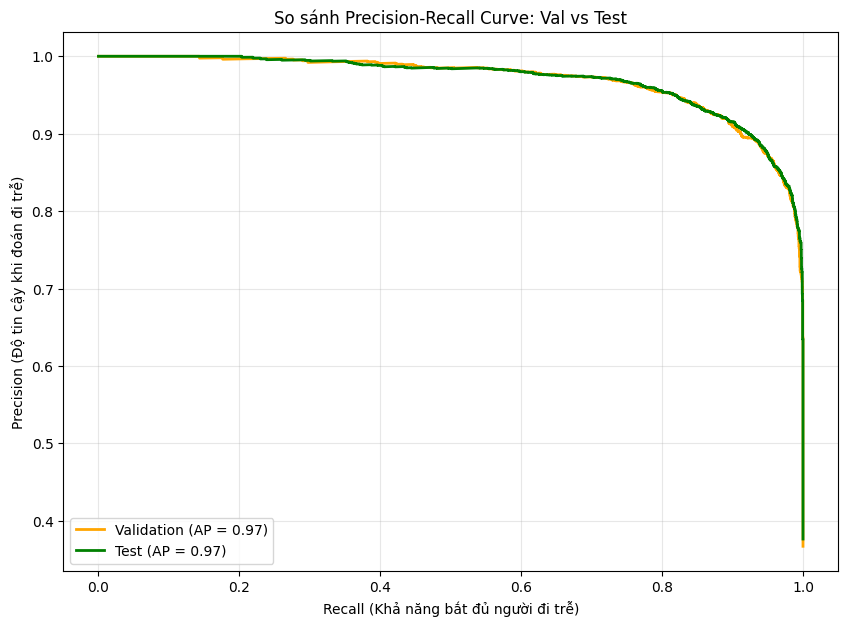

In [235]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_prob_val = rf.predict_proba(x_val)[:, 1]
y_prob_test = rf.predict_proba(x_test)[:, 1]

p_val, r_val, _ = precision_recall_curve(y_val, y_prob_val)
p_test, r_test, _ = precision_recall_curve(y_test, y_prob_test)

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))
plt.plot(r_val, p_val, label=f'Validation (AP = {average_precision_score(y_val, y_prob_val):.2f})', color='orange', lw=2)
plt.plot(r_test, p_test, label=f'Test (AP = {average_precision_score(y_test, y_prob_test):.2f})', color='green', lw=2)

plt.xlabel('Recall (Khả năng bắt đủ người đi trễ)')
plt.ylabel('Precision (Độ tin cậy khi đoán đi trễ)')
plt.title('So sánh Precision-Recall Curve: Val vs Test')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

### XGBoost model

In [236]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=50,       
    max_depth=4,            
    learning_rate=0.1,     
    subsample=0.8,         
    colsample_bytree=0.8,  
    eval_metric='logloss',
    random_state=42
)
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, ...)

In [237]:
print(f"Accuracy on val set: {xgb.score(x_val, y_val)}")
print(f"Accuracy on test set: {xgb.score(x_test, y_test)}")
print(f"Accuracy on train set: {xgb.score(x_train, y_train)}")

Accuracy on val set: 0.94125
Accuracy on test set: 0.941
Accuracy on train set: 0.9528958672789216


In [238]:
# du doan xac xuat di của index đầu tiên trong tập val
first_preson = x_val[0:1]
prob = xgb.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.92
Xác suất đi trễ (Lớp 1): 0.08


In [239]:
# du doan xac xuat di của index đầu tiên trong tập test
first_preson = x_test[0:1]
prob = xgb.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.55
Xác suất đi trễ (Lớp 1): 0.45


In [240]:
y_pred_test = xgb.predict(x_test)
y_pred_val = xgb.predict(x_val)

prediction_val = pd.DataFrame({"y": y_val, "y_pred_val": y_pred_val})
prediction_val.head(10)

,y,y_pred_val
0,0,0
1,0,0
2,1,1
3,1,0
4,0,0
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [241]:
prediction_test = pd.DataFrame({"y": y_test, "y_pred_test": y_pred_test})
prediction_test.head(10)

,y,y_pred_test
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [242]:
precision_score(y_test, y_pred_test),  recall_score(y_test, y_pred_test)     

(0.8999748047367095, 0.948738379814077)

In [243]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      6235
           1       0.90      0.95      0.92      3765

    accuracy                           0.94     10000
   macro avg       0.93      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



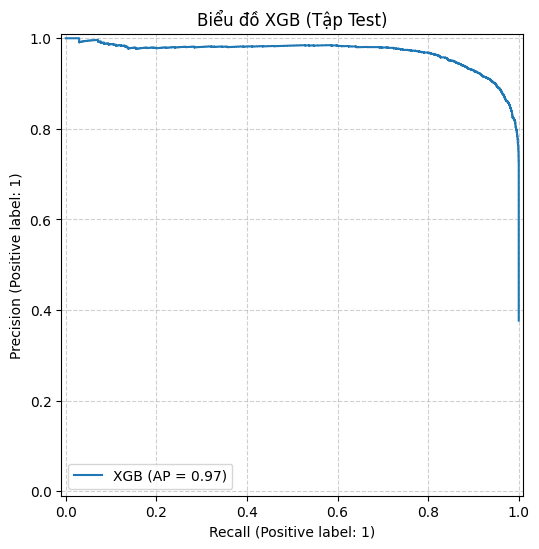

In [244]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(xgb, x_test, y_test, name="XGB", ax=ax)

ax.set_title("Biểu đồ XGB (Tập Test)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

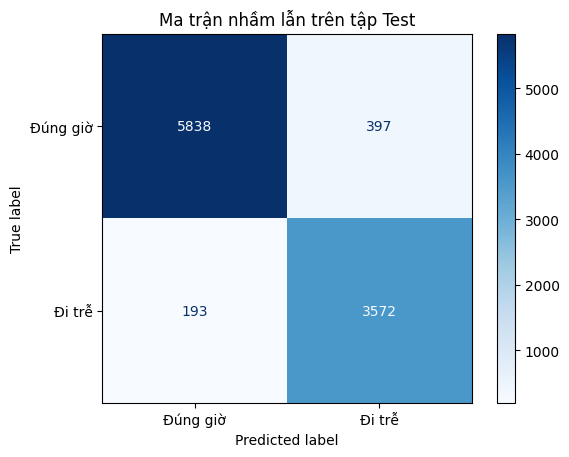

In [245]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(xgb, x_test, y_test, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()

<Figure size 800x600 with 0 Axes>

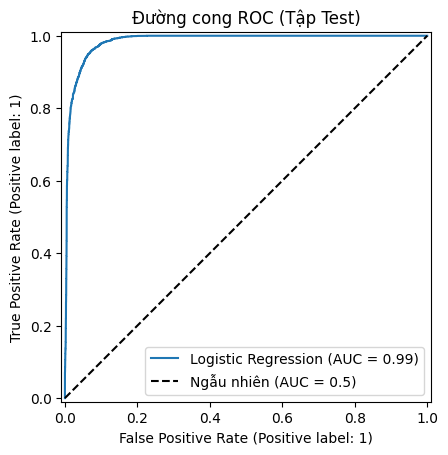

In [246]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb, x_test, y_test, name="Logistic Regression")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập Test)')
plt.legend()
plt.show()

In [247]:
precision_score(y_val, y_pred_val),  recall_score(y_val, y_pred_val)

(0.8909667194928684, 0.9570990806945863)

In [248]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      5063
           1       0.89      0.96      0.92      2937

    accuracy                           0.94      8000
   macro avg       0.93      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000



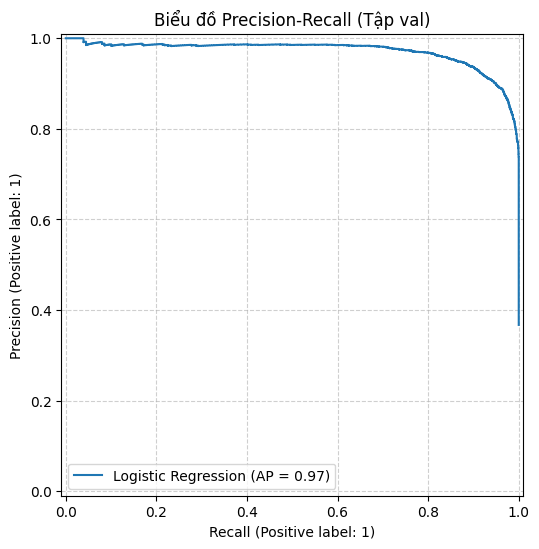

In [249]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(xgb, x_val, y_val, name="Logistic Regression", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập val)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

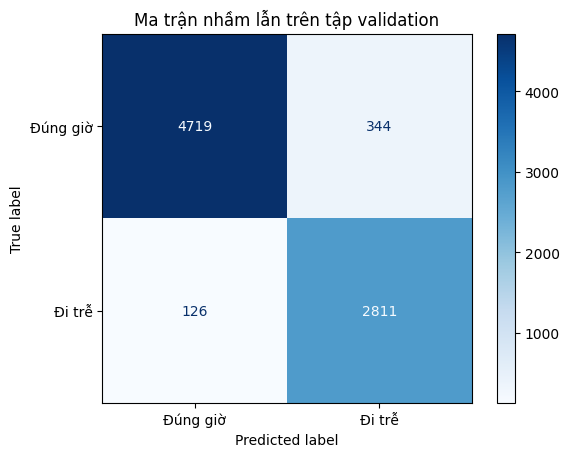

In [250]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(xgb, x_val, y_val, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập validation')
plt.show()

<Figure size 800x600 with 0 Axes>

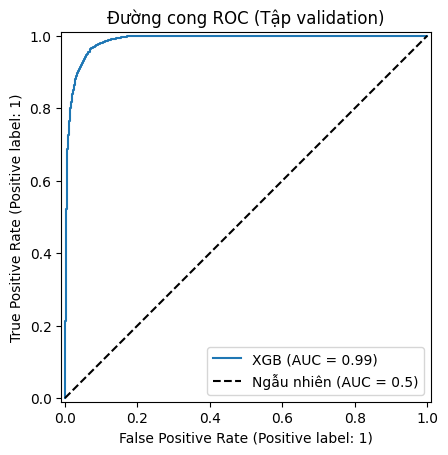

In [251]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(xgb, x_val, y_val, name="XGB")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập validation)')
plt.legend()
plt.show()

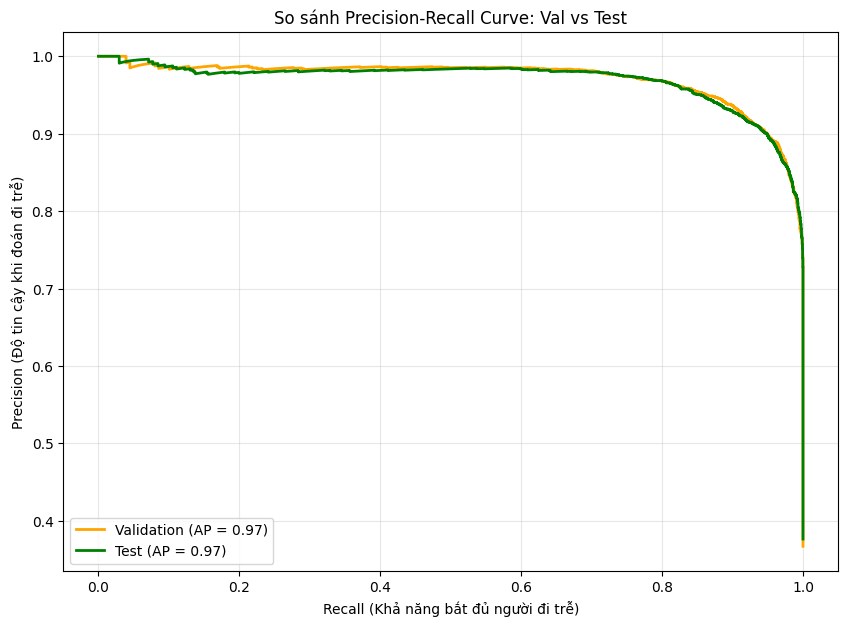

In [252]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_prob_val = xgb.predict_proba(x_val)[:, 1]
y_prob_test = xgb.predict_proba(x_test)[:, 1]

p_val, r_val, _ = precision_recall_curve(y_val, y_prob_val)
p_test, r_test, _ = precision_recall_curve(y_test, y_prob_test)

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))
plt.plot(r_val, p_val, label=f'Validation (AP = {average_precision_score(y_val, y_prob_val):.2f})', color='orange', lw=2)
plt.plot(r_test, p_test, label=f'Test (AP = {average_precision_score(y_test, y_prob_test):.2f})', color='green', lw=2)

plt.xlabel('Recall (Khả năng bắt đủ người đi trễ)')
plt.ylabel('Precision (Độ tin cậy khi đoán đi trễ)')
plt.title('So sánh Precision-Recall Curve: Val vs Test')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

### SVC model

In [253]:
from sklearn.svm import SVC

svc = SVC(
    kernel='rbf',           
    C=0.1,                  
    gamma='scale',           
    class_weight='balanced', 
    random_state=42,
    probability=True         
)
svc.fit(x_train, y_train)

SVC(C=0.1, class_weight='balanced', probability=True, random_state=42)

In [ ]:
print(f"Accuracy on val set: {svc.score(x_val, y_val)}")
print(f"Accuracy on train set: {svc.score(x_train, y_train)}")

Accuracy on val set: 0.9595
Accuracy on test set: 0.9588
Accuracy on train set: 0.9633387646274626


In [255]:
first_preson = x_val[0:1]
prob = svc.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.99
Xác suất đi trễ (Lớp 1): 0.01


In [256]:
first_preson = x_test[0:1]
prob = svc.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.95
Xác suất đi trễ (Lớp 1): 0.05


In [257]:
y_pred_test = svc.predict(x_test)
y_pred_val = svc.predict(x_val)

prediction_val = pd.DataFrame({"y": y_val, "y_pred_val": y_pred_val})
prediction_val.head(10)

,y,y_pred_val
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,1,1
7,0,0
8,1,1
9,1,1


In [258]:
prediction_test = pd.DataFrame({"y": y_test, "y_pred_test": y_pred_test})
prediction_test.head(10)

,y,y_pred_test
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


In [259]:
precision_score(y_test, y_pred_test),  recall_score(y_test, y_pred_test)     

(0.9207026348808031, 0.9745019920318725)

In [260]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      6235
           1       0.92      0.97      0.95      3765

    accuracy                           0.96     10000
   macro avg       0.95      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



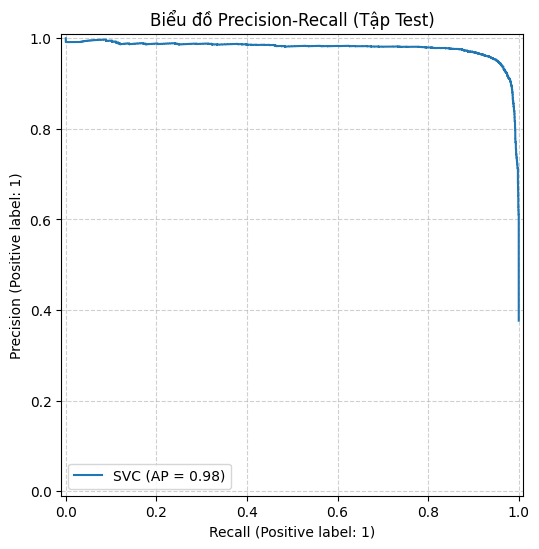

In [261]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(svc, x_test, y_test, name="SVC", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập Test)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

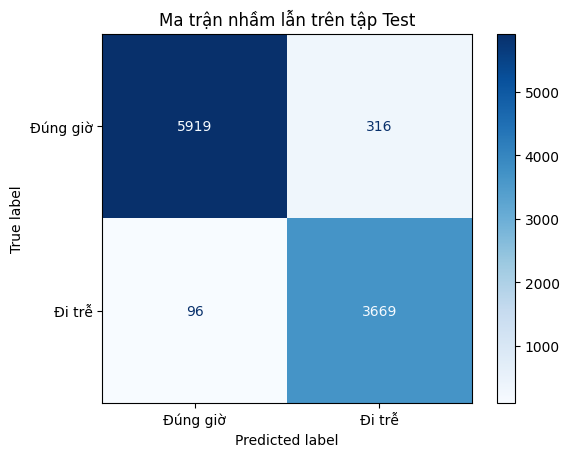

In [262]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(svc, x_test, y_test, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập Test')
plt.show()

<Figure size 800x600 with 0 Axes>

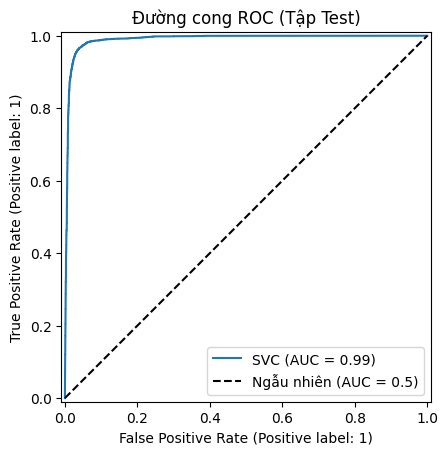

In [263]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(svc, x_test, y_test, name="SVC")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập Test)')
plt.legend()
plt.show()

In [264]:
precision_score(y_val, y_pred_val),  recall_score(y_val, y_pred_val)     

(0.9218598643848886, 0.972080354102826)

In [265]:
print(classification_report(y_val, y_pred_val))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      5063
           1       0.92      0.97      0.95      2937

    accuracy                           0.96      8000
   macro avg       0.95      0.96      0.96      8000
weighted avg       0.96      0.96      0.96      8000



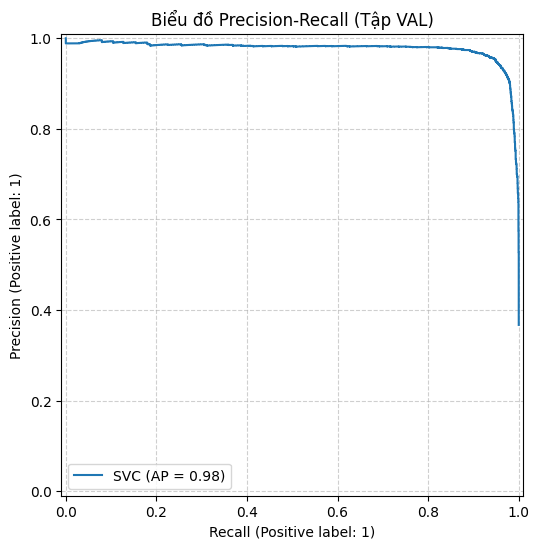

In [266]:
from sklearn.metrics import PrecisionRecallDisplay
fig, ax = plt.subplots(figsize=(8, 6))
display = PrecisionRecallDisplay.from_estimator(svc, x_val, y_val, name="SVC", ax=ax)

ax.set_title("Biểu đồ Precision-Recall (Tập VAL)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<Figure size 800x600 with 0 Axes>

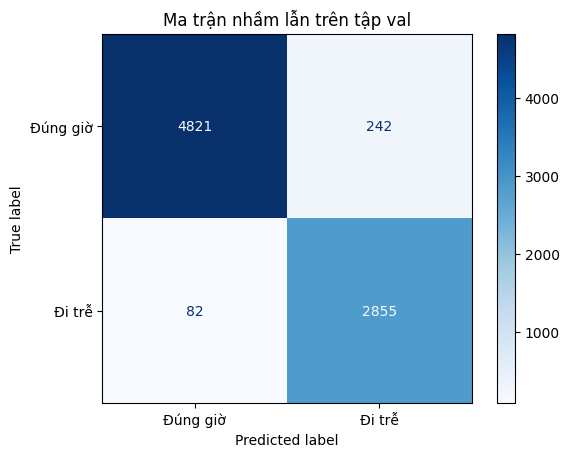

In [267]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(svc, x_val, y_val, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Blues')
plt.title('Ma trận nhầm lẫn trên tập val')
plt.show()

<Figure size 800x600 with 0 Axes>

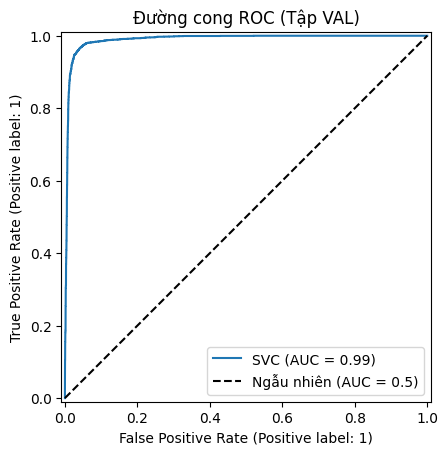

In [268]:
from sklearn.metrics import RocCurveDisplay
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(svc, x_val, y_val, name="SVC")
plt.plot([0, 1], [0, 1], 'k--', label='Ngẫu nhiên (AUC = 0.5)')
plt.title('Đường cong ROC (Tập VAL)')
plt.legend()
plt.show()

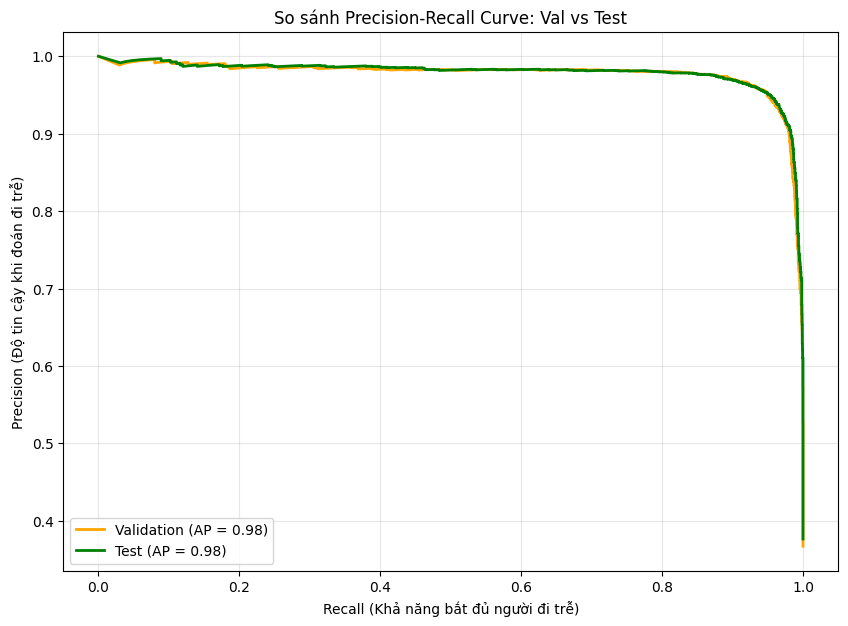

In [269]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_prob_val = svc.predict_proba(x_val)[:, 1]
y_prob_test = svc.predict_proba(x_test)[:, 1]

p_val, r_val, _ = precision_recall_curve(y_val, y_prob_val)
p_test, r_test, _ = precision_recall_curve(y_test, y_prob_test)

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))
plt.plot(r_val, p_val, label=f'Validation (AP = {average_precision_score(y_val, y_prob_val):.2f})', color='orange', lw=2)
plt.plot(r_test, p_test, label=f'Test (AP = {average_precision_score(y_test, y_prob_test):.2f})', color='green', lw=2)

plt.xlabel('Recall (Khả năng bắt đủ người đi trễ)')
plt.ylabel('Precision (Độ tin cậy khi đoán đi trễ)')
plt.title('So sánh Precision-Recall Curve: Val vs Test')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

### StackingClassifier

In [270]:
from sklearn.ensemble import StackingClassifier
import time


In [ ]:

base_models = [
    ('log_reg', LogisticRegression(class_weight='balanced', random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=10, min_samples_split=20, class_weight='balanced', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42)),
    ('xgb', XGBClassifier(n_estimators=25, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42))
]
stk = StackingClassifier(
    estimators=base_models,
    final_estimator=DecisionTreeClassifier(),
    cv=5, 
    n_jobs=-1,
    verbose=2
)
with tqdm(total=100, desc="Đang huấn luyện Stacking Classifier") as pbar:
    stk.fit(x_train, y_train)
    pbar.update(100)

Đang huấn luyện Stacking Classifier: 100%|██████████| 100/100 [00:30<00:00,  3.24it/s]


In [272]:
print(f"Accuracy on val set: {stk.score(x_val, y_val)}")
print(f"Accuracy on test set: {stk.score(x_test, y_test)}")
print(f"Accuracy on train set: {stk.score(x_train, y_train)}")

Accuracy on val set: 0.947
Accuracy on test set: 0.9508
Accuracy on train set: 0.9707697625043203


In [273]:
# du doan xac xuat di của index đầu tiên trong tập val
first_preson = x_test[0:1]
prob = stk.predict_proba(first_preson)
print(f"Xác suất đúng giờ (Lớp 0): {prob[0][0]:.2f}")
print(f"Xác suất đi trễ (Lớp 1): {prob[0][1]:.2f}")

Xác suất đúng giờ (Lớp 0): 0.55
Xác suất đi trễ (Lớp 1): 0.45


In [274]:
precision_score(y_test, y_pred_test),  recall_score(y_test, y_pred_test)     

(0.9207026348808031, 0.9745019920318725)

In [275]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      6235
           1       0.92      0.97      0.95      3765

    accuracy                           0.96     10000
   macro avg       0.95      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [276]:
y_pred_test = stk.predict(x_test)
prediction_test = pd.DataFrame({"y": y_test, "y_pred_test": y_pred_test})
prediction_test.head(10)

,y,y_pred_test
0,0,0
1,0,0
2,1,1
3,1,1
4,0,0
5,0,0
6,0,0
7,1,1
8,0,0
9,0,0


<Figure size 800x600 with 0 Axes>

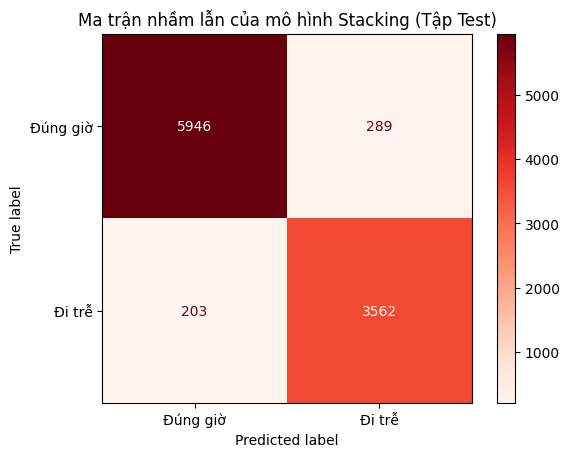

In [277]:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(stk, x_test, y_test, 
                                      display_labels=['Đúng giờ', 'Đi trễ'], 
                                      cmap='Reds')
plt.title('Ma trận nhầm lẫn của mô hình Stacking (Tập Test)')
plt.show()

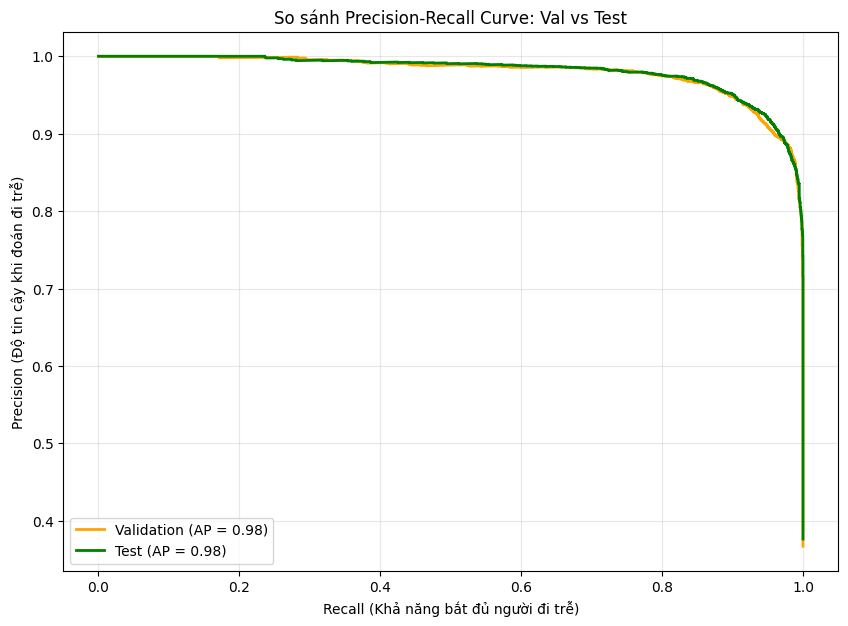

In [278]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_prob_val = stk.predict_proba(x_val)[:, 1]
y_prob_test = stk.predict_proba(x_test)[:, 1]

p_val, r_val, _ = precision_recall_curve(y_val, y_prob_val)
p_test, r_test, _ = precision_recall_curve(y_test, y_prob_test)

# Vẽ biểu đồ
plt.figure(figsize=(10, 7))
plt.plot(r_val, p_val, label=f'Validation (AP = {average_precision_score(y_val, y_prob_val):.2f})', color='orange', lw=2)
plt.plot(r_test, p_test, label=f'Test (AP = {average_precision_score(y_test, y_prob_test):.2f})', color='green', lw=2)

plt.xlabel('Recall (Khả năng bắt đủ người đi trễ)')
plt.ylabel('Precision (Độ tin cậy khi đoán đi trễ)')
plt.title('So sánh Precision-Recall Curve: Val vs Test')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

### so sanh

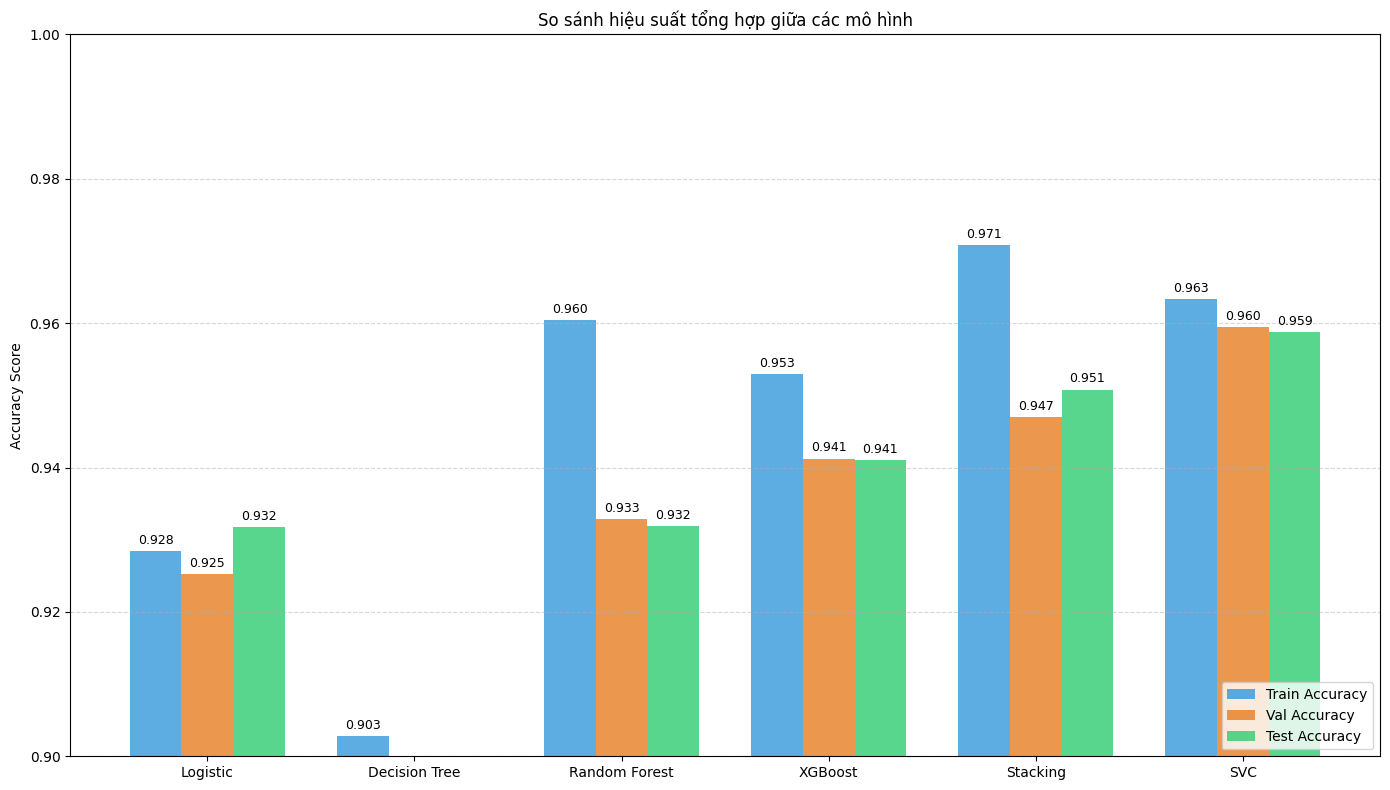

In [279]:
model_names = ['Logistic', 'Decision Tree', 'Random Forest', 'XGBoost', 'Stacking', 'SVC']
model_objects = [log_reg, dt, rf, xgb, stk, svc]

# 2. Tự động tính toán Accuracy từ các biến dữ liệu của bạn
train_accs = [m.score(x_train, y_train) for m in model_objects]
val_accs = [m.score(x_val, y_val) for m in model_objects]
test_accs = [m.score(x_test, y_test) for m in model_objects]

# 3. Cấu hình biểu đồ
x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 8))

# Vẽ các cột (Train, Val, Test)
ax.bar(x - width, train_accs, width, label='Train Accuracy', color='#3498db', alpha=0.8)
ax.bar(x, val_accs, width, label='Val Accuracy', color='#e67e22', alpha=0.8)
ax.bar(x + width, test_accs, width, label='Test Accuracy', color='#2ecc71', alpha=0.8)

# Định dạng trục và tiêu đề
ax.set_ylabel('Accuracy Score')
ax.set_title('So sánh hiệu suất tổng hợp giữa các mô hình')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.9, 1.0) # Tập trung vào vùng kết quả cao
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hiển thị số liệu chi tiết trên từng cột
def add_labels(rects):
    for rect in ax.patches:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

add_labels(None)
plt.tight_layout()
plt.show()

### Cross validation with k_fold 


In [280]:
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import time
from sklearn.metrics import get_scorer
import joblib
import os
from sklearn.base import clone
from tabulate import tabulate  # pip install tabulate nếu chưa có

seed = 42 

model = [
    LinearSVC(random_state=seed),
    SVC(random_state=seed),
    LogisticRegression(solver="liblinear", random_state=seed, max_iter=1001),
    DecisionTreeClassifier(random_state=seed),
    RandomForestClassifier(random_state=seed),
    GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=seed),
]



Bắt đầu Cross-Validation cho các model...



Models:  17%|█▋        | 1/6 [00:00<00:04,  1.07it/s, Current Model=SVC]      

Val Accuracy: 92.82% ± 0.0032 | Time: 0.93s   

|  Fold  |  Accuracy  |  Time (s)  |
|--------|------------|------------|
|   1    |   0.9283   |    0.13    |
|   2    |   0.9258   |    0.15    |
|   3    |   0.9335   |    0.12    |
|   4    |   0.9253   |    0.14    |
|   5    |   0.928    |    0.13    |

------------------------------------------------------------



Models:  33%|███▎      | 2/6 [02:29<05:52, 88.04s/it, Current Model=LogisticRegression]

Val Accuracy: 97.16% ± 0.0022 | Time: 149.01s   

|  Fold  |  Accuracy  |  Time (s)  |
|--------|------------|------------|
|   1    |   0.9715   |   29.53    |
|   2    |   0.9694   |   28.94    |
|   3    |   0.9752   |   30.86    |
|   4    |   0.9709   |   29.56    |
|   5    |   0.971    |   29.89    |

------------------------------------------------------------



...

Val Accuracy: 93.29% ± 0.0048 | Time: 2.29s   

|  Fold  |  Accuracy  |  Time (s)  |
|--------|------------|------------|
|   1    |   0.9387   |    0.43    |
|   2    |   0.9259   |    0.42    |
|   3    |   0.935    |    0.41    |
|   4    |   0.934    |    0.41    |
|   5    |   0.9309   |    0.41    |

------------------------------------------------------------



Models:  83%|████████▎ | 5/6 [03:09<00:32, 32.49s/it, Current Model=GradientBoostingClassifier]

Val Accuracy: 96.04% ± 0.0010 | Time: 36.67s   

|  Fold  |  Accuracy  |  Time (s)  |
|--------|------------|------------|
|   1    |   0.9612   |    7.34    |
|   2    |   0.9605   |    7.31    |
|   3    |   0.9606   |    7.3     |
|   4    |   0.9608   |    7.26    |
|   5    |   0.9587   |    7.25    |

------------------------------------------------------------



Models: 100%|██████████| 6/6 [03:33<00:00, 35.55s/it, Current Model=GradientBoostingClassifier]


Val Accuracy: 93.74% ± 0.0017 | Time: 23.42s   

|  Fold  |  Accuracy  |  Time (s)  |
|--------|------------|------------|
|   1    |   0.9372   |    4.69    |
|   2    |   0.9357   |    4.74    |
|   3    |   0.9403   |    4.46    |
|   4    |   0.9367   |    4.7     |
|   5    |   0.9374   |    4.61    |

------------------------------------------------------------



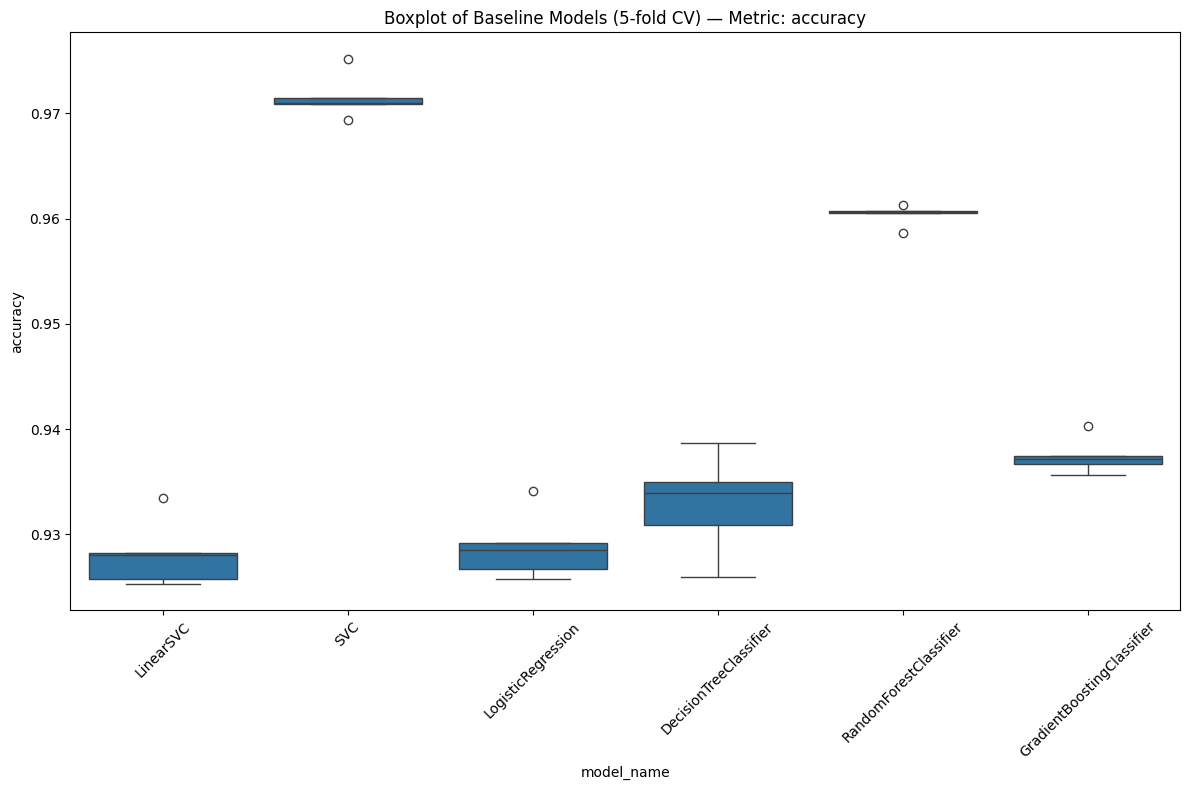

🏆 Tổng kết Cross-Validation tất cả model:
+---+----------------------------+--------+--------+
|   |         model_name         |  Mean  |  Std   |
+---+----------------------------+--------+--------+
| 0 |            SVC             | 0.9716 | 0.0022 |
| 1 |   RandomForestClassifier   | 0.9604 | 0.001  |
| 2 | GradientBoostingClassifier | 0.9374 | 0.0017 |
| 3 |   DecisionTreeClassifier   | 0.9329 | 0.0048 |
| 4 |     LogisticRegression     | 0.9289 | 0.0032 |
| 5 |         LinearSVC          | 0.9282 | 0.0032 |
+---+----------------------------+--------+--------+

🔥 Lưu TOP 3 model tốt nhất:
✅ Đang train lại & lưu: SVC
✅ Đang train lại & lưu: RandomForestClassifier
✅ Đang train lại & lưu: GradientBoostingClassifier

✅ Hoàn tất! Model lưu tại: D:\predictingStudentsLate\model


In [ ]:
save_dir = r"D:\predictingStudentsLate\model"
os.makedirs(save_dir, exist_ok=True)

def cross_val_score_kfold(
    model,
    x,
    y,
    metrics="accuracy",
    n_folds=5,
    seed=42,
    plot_result=False,
    save_top_k=6,
    preprocessor=None
):
    results = []

    print("Bắt đầu Cross-Validation cho các model...\n")

    # Progress bar chính cho các model
    model_pbar = tqdm(model, desc="Models", position=0, leave=True)

    for ml in model_pbar:
        model_name = ml.__class__.__name__
        model_pbar.set_postfix({"Current Model": model_name})

        fold_scores = []
        fold_times = []
        total_time_start = time.time()

        # Progress bar cho folds của từng model (giống training loop)
        fold_pbar = tqdm(
            range(1, n_folds + 1),
            desc=f"{model_name} CV",
            total=n_folds,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}{postfix}]",
            position=1,
            leave=True
        )

        for fold in fold_pbar:
            X_train, X_test, y_train, y_test = train_test_split(
                x,
                y,
                train_size=0.8,
                test_size=0.2,
                stratify=y,
                random_state=seed + fold
            )

            start_time = time.time()
            ml_fold = clone(ml)
            ml_fold.fit(X_train, y_train)

            if metrics == "accuracy":
                score = ml_fold.score(X_test, y_test)
            else:
                score = get_scorer(metrics)(ml_fold, X_test, y_test)

            fold_time = time.time() - start_time

            fold_scores.append(score)
            fold_times.append(fold_time)

            # Cập nhật postfix giống như training log (score hiện tại)
            fold_pbar.set_postfix({metrics: f"{score:.4f}"})

            results.append((model_name, fold, score, fold_time))

        fold_pbar.close()

        total_time = time.time() - total_time_start

        # Tính mean và std
        mean_score = sum(fold_scores) / n_folds
        std_score = pd.Series(fold_scores).std()

        # In dòng "Val" đẹp giống deep learning log
        print(f"Val {metrics.capitalize()}: {mean_score:.2%} ± {std_score:.4f} | "
              f"Time: {total_time:.2f}s   "
              f"{'✓ Best in this run' if mean_score == max([r[2] for r in results if r[0] == model_name]) else ''}\n")

        # In bảng chi tiết folds nếu muốn (tùy chọn)
        fold_df = pd.DataFrame({
            "Fold": range(1, n_folds + 1),
            metrics.capitalize(): [f"{s:.4f}" for s in fold_scores],
            "Time (s)": [f"{t:.2f}" for t in fold_times]
        })

        print(tabulate(
            fold_df,
            headers="keys",
            tablefmt="github",
            showindex=False,
            stralign="center",
            numalign="center"
        ))
        print("\n" + "-"*60 + "\n")

    # Tổng hợp kết quả
    cv_df = pd.DataFrame(
        results,
        columns=["model_name", "fold", metrics, "time_sec"]
    )

    if plot_result:
        plt.figure(figsize=(12, 8))
        sns.boxplot(x="model_name", y=metrics, data=cv_df)
        plt.title(f"Boxplot of Baseline Models ({n_folds}-fold CV) — Metric: {metrics}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Tổng kết bảng
    summary = cv_df.groupby("model_name")[metrics].agg(["mean", "std"]).round(4)
    summary.columns = ["Mean", "Std"]
    summary = summary.sort_values("Mean", ascending=False)

    print("🏆 Tổng kết Cross-Validation tất cả model:")
    print(tabulate(
        summary.reset_index(),
        headers="keys",
        tablefmt="pretty",
        floatfmt=".4f"
    ))

    # Lưu top k model
    top_models = summary.head(save_top_k).index.tolist()

    print(f"\n🔥 Lưu TOP {save_top_k} model tốt nhất:")
    for ml in model:
        model_name = ml.__class__.__name__
        if model_name in top_models:
            print(f"✅ Đang train lại & lưu: {model_name}")

            ml_clone = clone(ml)
            ml_clone.fit(x, y)

            save_data = {
                "model": ml_clone,
                "mean_cv_score": summary.loc[model_name, "Mean"],
                "std_cv_score": summary.loc[model_name, "Std"],
                "metric": metrics,
            }
            if preprocessor is not None:
                save_data['preprocessor'] = preprocessor

            joblib.dump(
                save_data,
                os.path.join(save_dir, f"{model_name}.pkl")
            )

    print(f"\n✅ Hoàn tất! Model lưu tại: {save_dir}")

# Gọi hàm
cross_val_score_kfold(
    model=model,   # list các model
    x=x_train,
    y=y_train,
    metrics="accuracy",  # hoặc "f1", "roc_auc",...
    n_folds=5,
    seed=42,
    plot_result=True,
    save_top_k=3,
    preprocessor=preprocessor  # nếu có
)

# DU DOAN XAC XUAT DI TRE CUA 1 SINH VIEN 

In [282]:
def predict_price_with_all_models(
    weekday, distance_km, weather, transport_mode,
    avg_speed_kmh, habitual_punctuality, sleep_hours,
    alarm_used, hour_start_time, traffic_condition, preparation_time, class_importance, unexpected_event
):
    input_data = pd.DataFrame({
        'weekday': [weekday],
        'distance_km': [distance_km],
        'weather': [weather],
        'transport_mode': [transport_mode],
        'avg_speed_kmh': [avg_speed_kmh],
        'habitual_punctuality': [habitual_punctuality],
        'sleep_hours': [sleep_hours],
        'alarm_used': [alarm_used],
        'hour_start_time': [hour_start_time],
        'traffic_condition': [traffic_condition],
        'preparation_time': [preparation_time],
        'class_importance': [class_importance],
        'unexpected_event': [unexpected_event]
        
        
    })

    try:
        input_encoded = preprocessor.transform(input_data)
    except Exception as e:
        print("❌ Lỗi transform dữ liệu:", e)
        return


    predictions = {}

    try:
        predictions["Linear Regression"] = log_reg.predict_proba(input_encoded)[0]
        # predictions["Linear Regression"] = log_reg.predict(input_encoded)
    except Exception as e:
        predictions["Linear Regression"] = f"Error: {e}"

    print("\n======== THÔNG TIN DỰ ĐOÁN ========\n")
    print(f"weekday: {weekday}")
    print(f"distance_km: {distance_km}")
    print(f"weather: {weather}")
    print(f"transport_mode: {transport_mode}")
    print(f"avg_speed_kmh: {avg_speed_kmh}")
    print(f"habitual_punctuality: {habitual_punctuality}")
    print(f"sleep_hours: {sleep_hours}")
    print(f"alarm_used: {alarm_used}")
    print(f"hour_start_time: {hour_start_time}")
    print(f"traffic_condition: {traffic_condition}")
    print(f"preparation_time: {preparation_time} phút")
    print(f"class_importance: {class_importance}")
    print(f"unexpected_event: {unexpected_event}")
    

    print("\n======== KẾT QUẢ DỰ ĐOÁN ========\n")
    for model, value in predictions.items():
        print(f"{model}: {value}")

    return predictions


weekday = 'Monday'
distance_km = 1
weather = 'rainy'
transport_mode = 'bike'
avg_speed_kmh = 23
habitual_punctuality = 0.65
sleep_hours = 5.8
alarm_used = 'no'
hour_start_time = 7
traffic_condition = 'heavy' 
preparation_time = 15.0 
class_importance = 'medium'
unexpected_event = "yes"

predict_price_with_all_models(
    weekday, distance_km, weather, transport_mode,
    avg_speed_kmh, habitual_punctuality, sleep_hours,
    alarm_used, hour_start_time, traffic_condition, preparation_time, class_importance, unexpected_event
)



======== THÔNG TIN DỰ ĐOÁN ========

weekday: Monday
distance_km: 1
weather: rainy
transport_mode: bike
avg_speed_kmh: 23
habitual_punctuality: 0.65
sleep_hours: 5.8
alarm_used: no
hour_start_time: 7
traffic_condition: heavy
preparation_time: 15.0 phút
class_importance: medium
unexpected_event: yes

======== KẾT QUẢ DỰ ĐOÁN ========

Linear Regression: [0.89742879 0.10257121]


{'Linear Regression': array([0.89742879, 0.10257121])}

In [283]:

def predict_late_by_student(student_id, weekday, weather):
    student_row = df[df["student_id"] == student_id].copy()
    if student_row.empty:
        print("student_id không tồn tại trong dataset")
        return
    

    student_row.loc[:, "weekday"] = weekday
    student_row.loc[:, "weather"] = weather
    
    # 3. transform bằng preprocessor giống lúc training
    try:
        X_encoded = preprocessor.transform(student_row)
    except Exception as e:
        print("❌ Lỗi transform :", e)
        return
    
    prob = log_reg.predict_proba(X_encoded)[0][1]
    
    print("\n===== THÔNG TIN DỰ ĐOÁN =====")
    print(f"student_id: {student_id}")
    print(f"weekday: {weekday}")
    print(f"weather: {weather}")
    
    print("\n===== XÁC XUẤT ĐI TRỄ =====")
    print(f"Xác suất đi trễ: {prob:.4f}")
    
    return prob


predict_late_by_student("N22DCQCN026", "Monday", "Sunny")


===== THÔNG TIN DỰ ĐOÁN =====
student_id: N22DCQCN026
weekday: Monday
weather: Sunny

===== XÁC XUẤT ĐI TRỄ =====
Xác suất đi trễ: 0.0173


C:\Users\trita\AppData\Local\Temp\ipykernel_14640\231712763.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'Sunny' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  student_row.loc[:, "weather"] = weather


np.float64(0.017275023605651973)

### Load model

In [284]:
import joblib
best_model = RandomForestClassifier(random_state=see)
best_model.fit(x, y)

# Lưu model + preprocessor vào 1 file (dễ nhất)
import os
os.makedirs(r'D:\predictingStudentsLate', exist_ok=True)

joblib.dump({
    'preprocessor': preprocessor,
    'model': best_model
}, r'D:\predictingStudentsLate\best_model_final.pkl')

print("Đã lưu model tốt nhất thành công!")

NameError: name 'see' is not defined